# Session 3, Part 1 • Identifying cell types in the immune compartment

In the previous session, we processed the full Wang + Burns endometrial datasets and annotated broad lineages. Now, we take the cells labelled `"Immune"` and start again from the raw counts.

**Why start again rather than just zoom in on the existing UMAP?** The highly variable genes selected for the whole-tissue analysis performed in Session 2 were optimised to capture large, more obvious differences between broad cell lineages. The subtler genes that distinguish one immune cell type from another, particularly between transcriptionally similar populations like monocytes/macrophages/cDC2s, might be missed in the cross-lineage HVG calculation, and therefore not appropriately represented in the scVI latent space, kNN graph, UMAP, and clustering. Re-running the entire pipeline on the immune cells alone optimises each of these steps to resolve differences that actually matter for immune cell identity, including rare states that may be functionally important in reproduction.

---

### Imports

In [ ]:
# —— RUN THIS BEFORE ANYTHING ELSE ———————————————————————————————
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive; drive.mount('/content/drive')
    %run /content/drive/MyDrive/immerge_workshop/codes/notebooks/setup_notebook.py

In [ ]:
import os
import gc
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp

import anndata as ad
import scanpy as sc
import scvi

from codes.utils.sc_utils import Barplot, quick_markers, filterTFIDF

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi      = 100, # ADJUST THIS TO INCREASE/DECREASE FIGURE DISPLAY SIZE (also effects notebook size and speed)
    dpi_save = 300,
    frameon  = False,
    figsize  = (5, 5)
)

warnings.simplefilter("ignore")

print("anndata:", ad.__version__)
print("scanpy: ", sc.__version__)
print("scvi:   ", scvi.__version__)

---

## 1. Configuration

In [ ]:
# —— DIRECTORIES —————————————————————————————————————————————————
DATA_DIR = os.path.join("data/")
OUT_DIR = os.path.join("results/temp/session3/")
os.makedirs(OUT_DIR, exist_ok=True)
sc.settings.figdir = os.path.join(OUT_DIR, "figures/")

# —— INPUT: PROCESSED OBJECT FROM NOTEBOOK 1 —————————————————————
PROCESSED_H5AD = os.path.join("results/temp/session3/adata_for_session3.h5ad")

# —— INPUT: THE ORIGINAL RAW FILES ———————————————————————————————
DATASETS = {
    "Burns 2026": os.path.join(DATA_DIR, "burns_f_2026.h5ad"),
    "Wang 2020": os.path.join(DATA_DIR, "wang_f_2020.h5ad"),
}

# —— REPRODUCIBILITY —————————————————————————————————————————————
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
scvi.settings.seed = RANDOM_SEED

### Downloading important files for the session

In [ ]:
if IN_COLAB:
    !gdown --folder "https://drive.google.com/drive/folders/1ZIr5bFIp2xnH2nc9LUJyIeg9GURW-1D7" -O "results/temp/"
    !gdown --folder "https://drive.google.com/drive/folders/1JMoY-bP1YetU_CWcrxtzWzdNuTATyiIZ?usp=sharing" -O "data/"

---

## 2. Loading the processed object and extracting the immune barcodes

Here, we load the processed and lineage-annotated object from Session 2, then extract a list of cell barcodes that correspond to those annotated as `"Immune"`. We will later use this list to subset the raw, un-processed object!

In [ ]:
# Load the processed whole-tissue object
adata_full = sc.read_h5ad(PROCESSED_H5AD)
print(adata_full)

In [ ]:
# Inspect the object to identify where lineage-level cell annotations are held
adata_full.obs.head(3)

In [ ]:
# Visualise the lineage-level annotations on the UMAP
LINEAGE_KEY = "lineage" # FILL IN THE COLUMN NAME HOLDING LINEAGE ANNOTATIONS

sc.pl.umap(
    adata_full,
    color = ["Dataset", LINEAGE_KEY],
    ncols = 2,
    legend_fontsize = 9
)

In [ ]:
# —— EXTRACT THE IMMUNE BARCODES —————————————————————————————————

# This builds a boolean (True/False) mask over all cells that distinguishes whether they were annotated
# as Immune or not, then uses it to pull out the matching row names (obs_names), i.e. the cell barcodes.
is_immune = adata_full.obs[LINEAGE_KEY].astype(str) == "Immune"
immune_barcodes = adata_full.obs_names[is_immune]

print(f"Immune cells in the processed object: {len(immune_barcodes):,} "
      f"({100 * len(immune_barcodes) / adata_full.n_obs:.1f}% of all cells)")

# —— IMMUNE CELLS PER DATASET ———————————————————————————————————— --> can be an exercise???
imm_per_dataset = adata_full.obs.loc[is_immune, "Dataset"].value_counts().to_dict()
print(f"Immune cells per dataset: {imm_per_dataset}")

---

## 3. Re-loading the raw data and subsetting to immune cells

In this section, we load the original, un-processed Wang and Burns files and subset each to only include the immune cells we identified in the processed/annotated object (`adata_full`). This workflow is important because these raw objects are **not annotated,** meaning we can not use any of their existing obs columns to perform this subsetting.

<details>
<summary><i>Fallback: import pre-saved immune barcodes</i></summary>

```python
barcodes_path = os.path.join(OUT_DIR, "immune_barcodes.txt")

with open(barcodes_path, "r") as f:
    immune_barcodes = f.read().splitlines()

print(f"Loaded {len(immune_barcodes):,} barcodes from: {barcodes_path}")
```

</details>

In [ ]:
adatas = {}

# Iterate across datasets (see Config block for dictionary details)
for k, v in DATASETS.items():
    raw = sc.read_h5ad(v)

    # Build the mask: True where this cell's barcode is in our immune list.
    mask = raw.obs_names.isin(immune_barcodes)

    # Use the mask to subset the raw per-dataset object to immune cells
    sub = raw[mask].copy()
    adatas[k] = sub      # save into dictionary

    # Report cell recovery: found vs expected. A mismatch could mean the barcodes
    # in the raw file do not match the processed object, which must be fixed before going further.
    n_found = sub.n_obs
    expected = imm_per_dataset.get(k, 0)
    print(f"{k}: {n_found:,} immune cells recovered "
          f"(expected {expected:,}) out of {raw.n_obs:,} total cells")
    if n_found != expected:
        print(f"  [WARNING] Mismatch of {abs(n_found - expected):,} cells. "
              "Check that raw and processed barcodes use the same format.")
    if n_found == 0:
        print(f"  [WARNING] No barcodes matched at all. Raw example: {raw.obs_names[0]}")
        print(f"            Immune list example: {immune_barcodes[0]}")

    del raw
    gc.collect()

# Report immune cell recovery
total_found = sum(a.n_obs for a in adatas.values())
print(f"\nTotal immune cells recovered: {total_found:,} of {len(immune_barcodes):,} expected")

In [ ]:
# Inspect the per-dataset objects
adatas

In [ ]:
# Remove objects that we will no longer use - good for saving memory!
del adata_full
gc.collect();

---

## 4. Concatenating the immune subsets

We now concatenate the two datasets to prepare for joint processing, including batch correction (analogous to workflow in Session 2). Specifying `join="inner"` keeps only genes present in both objects.

In [ ]:
adata = ad.concat(
    list(adatas.values()),
    axis = 0,
    join = "inner",         # intersection of genes across both datasets
)

In [ ]:
adata

In [ ]:
del adatas
gc.collect();

---

## 5. QC

In best practice, the "raw" data files that we load and concatenate in Sections 3 and 4 should already be quality-controlled and saved, including the calculation of per-cell metrics such as total RNA counts, detected number of genes (`n_genes_by_counts` or `n_genes`), and percent mitochondrial reads (`pct_counts_mito`), and per-library metrics such as Scrublet-predicted doublets.

Here, we just apply a gene-level filter to remove genes that are expressed in less than 3 cells (i,e., have no real signal). 

In [ ]:
sc.pp.filter_genes(adata, min_cells=3)
adata

---

## 6. Normalisation and log-transformation

Normalise gene expression in each cell such that the total number of counts per cell is equal. As shown in Session 2, this step is important for making sure that we can compare gene expression across different cells in our dataset, since differences in sequencing depth or capture efficiency could otherwise be mistaken for differences in biology.

In [ ]:
TARGET_SUM = 1e4

# Freeze raw counts in a separate layer for future use,
# such as what is required for HVG selection using the Seurat v3 method
adata.layers["counts"] = adata.X.copy()

# Normalise and log-transform
sc.pp.normalize_total(adata, target_sum=TARGET_SUM)
sc.pp.log1p(adata)

---

## 7. Recompute HVGs

This is the step that most justifies re-running the scRNA-seq pipeline again. We calculate 3,000 HVGs again, but now the ranking is computed *only across immune cells*. The resulting list is thus optimised to capture genes that distinguish immune cell populations, as you'll see below.

Note that we employ the Seurat v3 method to calculate HVGs (`flavor="seurat_v3"`), which expects raw counts. This is why we froze raw counts in the `layer="counts"` earlier.

In [ ]:
N_HVGS = 3000

sc.pp.highly_variable_genes(
    adata,
    n_top_genes = N_HVGS,
    flavor      = "seurat_v3",     # variance-stabilising method, expects raw counts
    layer       = "counts",
    subset      = False,           # keep all genes in the object and flag HVGs in .var
)

In [ ]:
# Visualise the HVGs by mean expression vs. variance
sc.pl.highly_variable_genes(adata, log=True)

We can now inspect some of the top-ranked highly variable genes that were identified within the immune compartment. **Look through this list yourself - do these genes make sense?**

In [ ]:
# Display the top 25 HVGs ranked by normalised variance within the immune compartment
hv = adata.var["highly_variable"].values

top = (
    adata.var.loc[hv]
    .sort_values("variances_norm", ascending=False)
    .head(25)[["means", "variances_norm"]]
)
display(top)

In [ ]:
# Save object before proceeding
adata.write(os.path.join(OUT_DIR, "endometrium_immune_preintegration.h5ad"))

---

## 8. Re-integrating the immune compartment with Harmony

With HVGs calculated, we can now generate reduce the dimensions of our data in a way that accounts for batch effects. We will perform PCA on the 3,000 HVGs, then use Harmony to correct this PCA embedding.

In [ ]:
# Create a subset of our AnnData that only contains the 3,000 HVGs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print(f"HVG object: {adata_hvg.n_obs:,} cells x {adata_hvg.n_vars:,} genes")

In [ ]:
# PCA is sensitive to the expression scale of each gene, so we scale here
sc.pp.scale(adata_hvg, max_value=10)

In [ ]:
# Perform PCA on the scaled data
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack", random_state=RANDOM_SEED)

In [ ]:
# —— INTEGRATE WITH HARMONY ——————————————————————————————————————
import harmonypy as hm

pcs = adata_hvg.obsm["X_pca"]   # shape (n_cells, n_PCs)

harmony_out = hm.run_harmony(
    pcs,
    adata_hvg.obs,
    "Dataset",
    random_state = RANDOM_SEED,
)

Z = harmony_out.Z_corr

adata_hvg.obsm["X_pca_harmony"] = np.asarray(Z)
print(f"Harmony-corrected embedding shape: {adata_hvg.obsm['X_pca_harmony'].shape}")

assert (adata.obs_names == adata_hvg.obs_names).all(), "Cell order mismatch!"
adata.obsm["X_pca_harmony"] = adata_hvg.obsm["X_pca_harmony"]

In [ ]:
# See what has changed after performing Harmony
adata

---

## 9. Visualise

> ### ✏️ Exercise 01 — kNN graph and UMAP
>
> Compute the k-nearest neighbour graph and UMAP from the data, then evaluate how the integration performed by plotting relevant co-variates on the UMAP.
>

<details>
<summary><i>Show solution</i></summary>

```python
K = 15
sc.pp.neighbors(adata, n_neighbors = K, use_rep = "X_pca_harmony")
sc.tl.umap(adata, random_state=RANDOM_SEED)

sc.pl.umap(
    adata,
    color = ["Dataset", "Donor_id"],
    size  = 4,
)
```

</details>

In [ ]:
# YOUR CODE HERE

---

## 10. Leiden clustering

In [ ]:
resolutions = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for res in resolutions:
    key = f"leiden_res_{res}"
    sc.tl.leiden(adata, resolution=res, key_added=key,
                 flavor="igraph", n_iterations=2, directed=False)
    print(f"resolution {res:<4} -> {adata.obs[key].nunique():>3} clusters")

sc.pl.umap(adata, color=[f"leiden_res_{r}" for r in resolutions],
           legend_loc="on data", legend_fontsize=6, ncols=3, size=4)

> ### ✏️ Exercise 02 — Which immune cells do we have?
>
> Build a list of markers for your all favourite immune cell types, and plot them on both (1) the UMAP, and (2) a dotplot grouped by a Leiden resolution of your choice. Gene expression patterns that you observe on the UMAP may motivate you to pick one Leiden resolution over the other, depending on which are able to resolve differences between certain immune cell types.
>

<details>
<summary><i>Example solution</i></summary>

```python
imm_markers = {
    "Lymphoid":     ["CD3E", "GNLY"],
    "Myeloid":      ["CD14", "LYZ"],
    "NK":           ["NKG7", "NCR1", "NCAM1", "FCGR3A"], # NCAM1 = CD56; FCGR3A = CD16
    "T":            ["CD3D", "CD8A", "CD4"],
    "B / Plasma":   ["CD79A", "MS4A1", "MZB1", "JCHAIN"],
    "Monocyte":     ["CDA", "S100A12"],
    "Macrophage":   ["CSF1R", "CD68", "CQ1C"],
    "cDC1 / cDC2":  ["FLT3", "CLEC9A", "CD1C"],
    "Cycling":      ["MKI67", "TOP2A"],
}

imm_markers = {k: [g for g in v if g in adata.var_names] for k, v in imm_markers.items()}
imm_markers = {k: v for k, v in imm_markers.items() if v}
print("Markers found for:", list(imm_markers))

# Plot UMAP
for k, v in imm_markers.items():
    print(f"Plotting {k} markers...")
    sc.pl.umap(
        adata,
        color = v,
        size  = 4
    )
    
# Plot dot plot 
RES = "leiden_1.0"

sc.pl.dotplot(
    adata,
    markers,
    groupby        = RES,
    standard_scale = "var",
)

```

</details>

In [ ]:
# YOUR CODE HERE

> ### ✏️ Exercise 03 — Search for contamination
>
> Another benefit of zooming into a lineage is that it may better resolve clusters of cross-lineage doublets that may have been missed in the whole-tissue manifold. Plot some markers of non-immune lineages on your data (UMAP or dotplot) - do you think we have contamination? If so, what is the minimum Leiden resolution you need to isolate this contamination as a single cluster?
>

<details>
<summary><i>Example solution</i></summary>

```python
markers = {
    "Epithelial":    ["EPCAM", "KRT8", "KRT18", "CDH1"],
    "Secretory epi": ["PAEP", "GPX3", "CXCL14"],
    "Ciliated epi":  ["FOXJ1", "PIFO", "TPPP3"],
    "Stromal":       ["DCN", "COL1A1", "LUM", "MME"],
    "Endothelial":   ["PECAM1", "VWF", "CDH5"],
    "Perivascular":  ["ACTA2", "RGS5", "NOTCH3", "MCAM"],
}
markers = {k: [g for g in v if g in adata.var_names] for k, v in markers.items()}
markers = {k: v for k, v in markers.items() if v}
print("markers found for:", list(markers))

sc.pl.dotplot(
    adata,
    markers,
    groupby        = RES,
    standard_scale = "var",
)
```

</details>

In [ ]:
## YOUR CODE HERE

---

## 11a. Identifying cluster markers with the Wilcoxon rank-sum test

For one gene and one cluster, `sc.tl.rank_genes_groups` compares expression in that cluster against expression in all other cells. The **Wilcoxon rank-sum test** (equivalent to the Mann-Whitney U test) does this without assuming any particular distribution:

1. Pool all cells and rank them by expression of that gene, lowest to highest.
2. Add up the ranks belonging to cells in the cluster of interest.
3. Ask: is that rank sum larger than you would expect if cluster membership was unrelated to expression?

The output columns:

- `names` — the gene
- `scores` — the test statistic (z-score); higher means more strongly enriched in this cluster
- `logfoldchanges` — log2 fold change of mean expression, cluster vs rest
- `pvals` / `pvals_adj` — raw and Benjamini-Hochberg-adjusted p-values. BH correction controls the expected *proportion* of false positives among the genes you call significant, which matters when testing many (~20,000) genes at once.
- `pts` / `pts_rest` — fraction of cells expressing the gene, in the cluster and outside it (enabled by `pts=True`). Often more useful than fold change for annotation: a good marker is expressed in most of the cluster and few cells elsewhere.

In [ ]:
RES = "leiden_res_1.5"

sc.tl.rank_genes_groups(
    adata,
    groupby   = RES,
    method    = "wilcoxon",
    pts       = True,                    # also report the fraction of cells expressing each gene
    key_added = "rank_genes_wilcoxon",   # where results go in .uns
)

print("Results stored in adata.uns['rank_genes_wilcoxon']")
print(f"Groups tested: {list(adata.uns['rank_genes_wilcoxon']['names'].dtype.names)}")

In [ ]:
# Visualise top markers per cluster
sc.pl.umap(
    adata,
    color = RES,
    size  = 4,
    legend_loc = "on data",
    legend_fontsize = 8
)


sc.pl.rank_genes_groups(
    adata,
    n_genes  = 15,                      # top 15 genes per cluster
    sharey   = False,                   # each panel gets its own y scale
    key      = "rank_genes_wilcoxon",
    fontsize = 8,
)

In [ ]:
# Gather the results into one dataframe
markers = sc.get.rank_genes_groups_df(adata, group=None, key="rank_genes_wilcoxon")

# —— APPLY SENSIBLE FILTERS FOR ANNOTATION PURPOSES ——————————————
# These are practical thresholds for shortlisting markers.
# We want genes that are: statistically flagged, up in the cluster,
# expressed in most of the cluster.
markers_filt = markers[
    (markers["pvals_adj"] < 0.05) &        # adjusted p-value threshold
    (markers["logfoldchanges"] > 0.5) &    # up-regulated in the cluster
    (markers["pct_nz_group"] > 0.25)       # expressed in >25% of cluster cells
].copy()

# Sort so the strongest marker for each cluster appears first.
markers_filt = markers_filt.sort_values(["group", "scores"], ascending=[True, False])

print(f"Marker rows before filtering: {len(markers):,}")
print(f"After filtering: {len(markers_filt):,}")

In [ ]:
# —— DISPLAY TOP N MARKERS FOR A SPECIFIED CLUSTER ——
N = 15
CLUSTER = "3"

top_n_cluster = (
    markers_filt[markers_filt["group"] == CLUSTER]
    .head(N)
)

print(f"Top {N} markers for cluster {CLUSTER}:")
display(top_n_cluster)

We can use a specific function to plot the top N identified markers per cluster by the Wilcoxon test.

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes        = 5,                       # top 4 per cluster keeps the plot readable
    key            = "rank_genes_wilcoxon",
    standard_scale = "var",                   # scale each gene 0-1 so no gene dominates
    save           = "Wilcoxon_markers.pdf"
)

In [ ]:
# Save the markers to a spreadsheet for later reference
MARKERS_CSV = os.path.join(OUT_DIR, "immune_cluster_markers_wilcoxon.csv")

markers_filt.to_csv(MARKERS_CSV, index=False)
print(f"Written to: {MARKERS_CSV}")

## 11b. Identifying cluster markers with TF-IDF

TF-IDF (Term Frequency–Inverse Document Frequency) is a text-mining technique adapted here for single-cell data [Young & Behjati, 2020](https://academic.oup.com/gigascience/article-lookup/doi/10.1093/gigascience/giaa151). Each cluster is treated as a document and each gene as a word: genes highly expressed within one cluster but rare elsewhere score highly. This is achieved through binarizing gene expression before calculating its frequency within each cluster. We find that it performs better than standard DGE methods, such as the Wilcoxon rank-sum test, in pinpointing true cluster-specific *markers* in the data.

In [ ]:
# —— TF-IDF PARAMETERS ————————————————————————————————————————
RES = "leiden_res_1.5"

TFIDF_DOWNSAMPLE_N = 100
TFIDF_FDR          = 0.01
TFIDF_EXPRESS_CUT  = 0.9

In [ ]:
# —— DOWNSAMPLE CELLS PER GROUP ———————————————————————————————
# Prevents large clusters from dominating TF-IDF scores.
# Groups smaller than TFIDF_DOWNSAMPLE_N are kept in full.
cells_down = (
    adata.obs
    .groupby(RES, observed=True)
    .apply(lambda g: g.sample(min(len(g), TFIDF_DOWNSAMPLE_N), random_state=RANDOM_SEED))
    .index.get_level_values(-1)
)
adata_down = adata[cells_down].copy()
print(f"Downsampled: {adata_down.n_obs} cells across {adata_down.obs[RES].nunique()} groups")

In [ ]:
# —— RUN TF-IDF ———————————————————————————————————————————————
tfidf_markers = quick_markers(
    adata_down,
    cluster_key = RES,
    layer       = "counts",  # expects raw counts
    n_markers   = 200,
    fdr         = TFIDF_FDR,
    express_cut = TFIDF_EXPRESS_CUT,
)

TFIDF_CSV = os.path.join(OUT_DIR, f"tfidf_markers_{RES}.csv")
tfidf_markers.to_csv(TFIDF_CSV, index=False)
print(f"TF-IDF markers saved → {TFIDF_CSV}")
tfidf_markers.head(5)

In [ ]:
# Dotplot of top TF-IDF markers per Leiden cluster
lst_tfidf_markers = filterTFIDF(tfidf_markers, N=4) # we typically increase N to 10-20 to explore more markers!
sc.pl.dotplot(
    adata_down,
    lst_tfidf_markers,
    groupby        = RES,
    standard_scale = "var",
    save           = "tfidf_markers.pdf"
)

---

## 12. Cell type annotation

> ### ✏️ Exercise 04 — Time to annotate!
>
> Use the marker plotting exercises above to annotate the clusters with the code below. Feel free to re-perform Leiden clustering and the Wilcoxon rank-sum test to fine-tune your annotation resolution as needed. In practice, this is a very iterative process, especially for complex datasets!
>

In [ ]:
labels = {
    "0": "celltype_1",
    "1": "celltype_2",
    # "2": "Macrophage",
    # ... one entry per cluster
}

adata.obs["my_annotation"] = (adata.obs[RES].map(labels))

print("Cell count per annotation:")
print(adata.obs["cell_type"].value_counts())

In [ ]:
# Visualise your annotations
sc.pl.umap(
    adata,
    color           = "my_annotation",
    size            = 4,
    legend_loc      = "right margin",  # or "right margin", whatever you prefer
    legend_fontsize = 7,
)

### Validate your annotations

In [ ]:
# Validate annotations by plotting markers on a dot plot
sc.pl.dotplot(
    adata,
    imm_markers,            # or your custom dictionary
    groupby        = "my_annotation",
    standard_scale = "var",
)

In [ ]:
# Plot cell type distribution across donors
Barplot(
    which_var  = "my_annotation",
    adata      = adata,
    var        = "Donor_id",
    height     = 8,
    legendcols = 1,
)

In [ ]:
# Plot cell type distribution across donors
Barplot(
    which_var  = "my_annotation",
    adata      = adata,
    var        = "Menstrual_stage",
    height     = 2,
    legendcols = 1,
)

### Compare your annotations with ours!

In [ ]:
# Map VenTo Lab annotations onto object
ANN_CSV  = os.path.join("results/temp/session3/Cohen2026_annotations.csv")

prior = pd.read_csv(ANN_CSV, index_col="barcode")
adata.obs["Cohen2026_annotation"] = adata.obs_names.map(prior["fine_celltype"])
n_mapped = adata.obs["Cohen2026_annotation"].notna().sum()
print(f">> {n_mapped:,} / {adata.n_obs:,} cells annotated!\n")
print(adata.obs["Cohen2026_annotation"].value_counts(dropna=False))

In [ ]:
sc.pl.umap(
    adata,
    color = ["my_annotation", "Cohen2026_annotation"],
    size  = 4,
    ncols = 2,
    legend_fontsize = 9,
)

In [ ]:
# Plot cell type distribution across donors
Barplot(
    which_var  = "Cohen2026_annotation",
    adata      = adata,
    var        = "my_annotation",
    height     = 2,
    legendcols = 1,
)

### Save your annotated object before proceeding with downstream analysis

In [ ]:
# Save object before proceeding
adata.write(os.path.join(OUT_DIR, "endometrium_immune_annotated.h5ad"))

---

# Session 3, Part 2 • Examples of downstream analysis

## 13. Case-control differential gene expression analysis

A common question that scRNA-seq is useful for answering is whether certain cell types exhibit transcriptomic changes in response to disease or treatment. The most straightforward way to determine this is by performing **psuedobulk differential gene expression (DGE/DEG) analysis.**

In this example, we'll perform this analysis on a subset of endometrial stromal cells and see how they respond to the transition from the **proliferative** to **secretory** phase of the menstrual cycle.

**Pipeline:** based on the [**Pseudobulk Enrichment Analysis** tutorial](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html) by `decoupler`.
1. Load annotated .h5ad object containing raw counts.
2. Subset AnnData to groups (typically cell types) of interest in order to perform targeted DEG analysis.
3. Pseudobulk the data by donor x group.
4. Filter out low-quality pseudobulk samples and lowly expressed genes.
5. Run DESeq2 to identify pairwise differentially expressed genes.
6. Plot top DEGs on a volcano plot.
7. Save all upregulated and downregulated DEGs.

In [ ]:
import decoupler as dc
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [ ]:
# —— DGE ANALYSIS PARAMETERS ——————————————————————————————————
DONOR_COL  = "Donor_id"
GROUPS_COL = "Menstrual_stage"              # column name that will be used for comparison
GROUPS     = ["Proliferative", "Secretory"] # used for naming output files/columns later on

FDR = 0.05

In [ ]:
# Load endometrial mesenchymal data
adata = sc.read_h5ad(os.path.join(OUT_DIR, "endometrium_mesenchymal_annotated.h5ad"))
adata.obs["celltype"].value_counts()

First, we subset to our cells and/or groups of interest. How you subset should be tuned to fit your specific biological question!

In [ ]:
# —— SUBSET TO CELLS/GROUPS OF INTEREST ———————————————————————
n_before = adata.n_obs

SUB_GROUPS_DICT = {
    "celltype": ["Mesen_EndoStromalFib"],
    # "Donor_id": ["Donor_1", "Donor_2"] # not needed here, but an example
}

# Report what is being subset
subgroup_str = " and ".join(
    f"{col} = {', '.join(values)}"
    for col, values in SUB_GROUPS_DICT.items()
)
print(f"Subsetting to {subgroup_str}...")

# Create subsetting mask
mask = pd.Series(True, index=adata.obs.index) # initialise mask

for col, values in SUB_GROUPS_DICT.items():
    mask &= adata.obs[col].isin(values)

adata_sub = adata[mask].copy()
print(f"\n>> {adata_sub.n_obs} \ {n_before} cells kept")

**Create pseudobulk samples:**

`pdata` is an AnnData object, where:
* Each row (`obs`) is one pseudobulk sample (donor x cell type)
* Each column (`var`) is a gene
* `pdata.obs` contains donor, cell type, and QC columns
    * `psbulk_cells`: number of cells aggregated
    * `psbulk_counts`: total counts in that pseudobulk sample

Note that `obs` columns are only carried over if it has the **same value** across the pseudobulk level (i.e., donor).

In [ ]:
pdata = dc.pp.pseudobulk(
    adata       = adata_sub,
    sample_col  = DONOR_COL,
    groups_col  = GROUPS_COL,
    mode        = "sum",
    layer       = "counts",
    skip_checks = True
)

pdata

The following plot shows each pseudobulk sample as a point, with number of cells on one axis and total counts on the other. Samples in the lower-left corner are likely low quality, and can be excluded from the analysis using `dc.pp.filter_samples()`.

Filter thresholds are always dataset-dependent and arbitrary, but a common guideline is to retain samples with at least **10 cells** and **1000 total counts.**

In [ ]:
# —— Visualise QC metrics before filtering —————————————————————————————
MIN_CELLS  = 10
MIN_COUNTS = 1000

QC_METRICS = [DONOR_COL, GROUPS_COL]

for METRIC in QC_METRICS:
    # —— Conditionally suppress legend if too many group levels ————————
    n_levels = pdata.obs[METRIC].nunique()
    legend_setting = "auto" if n_levels <= 10 else False
    
    dc.pl.filter_samples(
        adata          = pdata,
        groupby        = [METRIC],
        min_cells      = MIN_CELLS,
        min_counts     = MIN_COUNTS,
        figsize        = (6,3),
        kw_scatterplot = {"legend": legend_setting}
    )

In [ ]:
del adata_down
del adata_hvg
gc.collect()

In [ ]:
# —— Apply the filter ——————————————————————————————————————————————————
pre_filt_cells = pdata.n_obs
print(f"Retaining samples with at least {MIN_CELLS} cells and {MIN_COUNTS} counts...")
dc.pp.filter_samples(
    pdata,
    min_cells  = MIN_CELLS,
    min_counts = MIN_COUNTS
)
post_filt_cells = pdata.n_obs
print(f">> {pre_filt_cells - post_filt_cells} pseudobulk samples removed.\n")
pdata

> ### ✏️ Exercise 05 — Review our pseudobulks
>
> Balancing group sizes maximises the power of this pairwise analysis. Inspect the metadata of the remaining pseudobulks in our dataset. How is the balance between the groups we are comparing here (Proliferative vs. Secretory menstrual cycle stage)?
>

<details>
<summary><i>Show solution</i></summary>

```python
pdata.obs # Groups are balanced!
```

</details>

In [ ]:
# YOUR CODE HERE

**Filter genes:**

Lowly expressed genes will also be filtered prior to downstream analysis. This step should be performed at the group (i.e., cell type) level, as different cell types may express distinct sets of genes. The following step uses the default parameters as specified in the `decoupler` Pseudobulk Enrichment Analysis tutorial.

The following function stores the filtered pseudobulk AnnDatas for each subset in a dictionary, keyed by subset name, so it is ready to pass directly into DESeq2 in the next step without recomputing.

In [ ]:
# —— Filter genes across the full pdata ————————————————————————————————
pdata_filtered = pdata.copy()

dc.pp.filter_by_expr(
    adata           = pdata_filtered,
    group           = GROUPS_COL,
    min_count       = 10,
    min_total_count = 15,
    large_n         = 10,
    min_prop        = 0.7
)

dc.pp.filter_by_prop(
    adata     = pdata_filtered,
    min_prop  = 0.1,
    min_smpls = 2
)

print(f"Genes remaining after filtering: {pdata_filtered.shape[1]}")

### Run DESeq2

In [ ]:
# —— Define a reusable DEG filter function —————————————————————————————
def filter_degs(
    results_df,
    padj_thresh:  float=0.05,
    lfc_thresh:   float=1.0
):
    """
    Filters a PyDESeq2 results DataFrame to significant DEGs.

    Parameters
    ----------
    results_df : pd.DataFrame
        Output from DeseqStats.results_df
    padj_thresh : float
        Adjusted p-value threshold. Default 0.05
    lfc_thresh : float
        Absolute log2 fold change threshold. Default 1.0 (i.e. 2-fold)
    """
    mask = (
        (results_df["padj"] < padj_thresh) &
        (results_df["log2FoldChange"].abs() > lfc_thresh)
    )
    return results_df[mask].sort_values("padj")

In [ ]:
# —— Extract counts and metadata as DataFrames for PyDESeq2 ————————————
counts_df = pd.DataFrame(
    pdata_filtered.X,
    index   = pdata_filtered.obs_names.astype(str),
    columns = pdata_filtered.var_names
)
counts_df = counts_df.round().astype(int)

metadata_df = pdata_filtered.obs[[GROUPS_COL]].copy()
metadata_df.index = metadata_df.index.astype(str)

# —— Initialise and fit DESeq2 —————————————————————————————————————————
inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    counts      = counts_df,
    metadata    = metadata_df,
    design      = f"~{GROUPS_COL}",
    refit_cooks = True,
    inference   = inference
)

dds.deseq2()

# —— Extract pairwise contrast and run Wald test ———————————————————————
stat_res = DeseqStats(
    dds,
    contrast  = [GROUPS_COL, GROUPS[0], GROUPS[1]],
    alpha     = FDR,
    inference = inference
)
stat_res.summary()

results               = stat_res.results_df
results["comparison"] = f"{GROUPS[0]}_vs_{GROUPS[1]}"

# —— Filter to significant DEGs ————————————————————————————————————————
sig_results = filter_degs(
    results,
    padj_thresh = FDR,
    lfc_thresh  = 1.0
)

print(f"\nSignificant DEGs ({GROUPS[0]} vs {GROUPS[1]}): {len(sig_results)}")

### Visualise DEGs

In [ ]:
# DEGs are most commonly 
fig = dc.pl.volcano(
    data       = results,
    x          = "log2FoldChange",
    y          = "pvalue",
    top        = 10,
    figsize    = (5, 4),
    return_fig = True
)

fig.axes[0].set_title(
    f"{GROUPS[0]} vs {GROUPS[1]}",
    fontsize = 12,
    pad      = 10
)

fig.savefig(
    f"{OUT_DIR}figures/volcano_DEGs.png",
    dpi=300,
    bbox_inches = "tight"
)

plt.show()

In [ ]:
# Select top DOTPLOT_TOP_N DEGs per group
DOTPLOT_TOP_N = 20

top_up = (
    sig_results[sig_results["log2FoldChange"] > 0]
    .nsmallest(DOTPLOT_TOP_N, "padj")
    .index.tolist()
)
top_down = (
    sig_results[sig_results["log2FoldChange"] < 0]
    .nsmallest(DOTPLOT_TOP_N, "padj")
    .index.tolist()
)

marker_dict = {
    GROUPS[0]: top_up,
    GROUPS[1]: top_down
}

# Plot DEGs in a dotplot
adata_plot = adata_sub.copy()
adata_plot = adata_plot[adata_plot.obs[GROUPS_COL].isin(GROUPS)].copy()

with plt.rc_context({"figure.dpi": 100}):

    dp = sc.pl.DotPlot(
        adata_plot,
        var_names      = marker_dict,
        groupby        = GROUPS_COL,
        standard_scale = "var",
    ).style(
        dot_edge_lw    = 0.5
    ).legend(
        colorbar_title = "Mean expr\n(scaled)"
    )

    dp.savefig(
        f"{OUT_DIR}figures/dotplot_DEGs.pdf",
        dpi=300,
        bbox_inches = "tight"
)

### Save DEGs

In [ ]:
# —— Compute fraction of cells expressing each DEG per group ——————————
# For each significant DEG and each group in GROUPS, compute the
# proportion of cells with non-zero expression.

X_bin = (
    (adata_sub.X.toarray() > 0)
    if sp.issparse(adata_sub.X)
    else (np.asarray(adata_sub.X) > 0)
).astype(int)
# X_bin shape: (n_cells, n_genes) — 1 where gene is expressed, 0 elsewhere.
# We binarise at > 0: any non-zero raw count counts as expressed.

gene_to_idx = pd.Series(
    np.arange(adata_sub.n_vars),
    index = adata_sub.var_names
)
# Maps each gene name to its column position in X_bin for fast lookup

for group in GROUPS:

    group_mask = (adata_sub.obs[GROUPS_COL] == group).values
    X_group    = X_bin[group_mask, :]
    n_cells    = group_mask.sum()
    col_name   = f"pct_expressed_{group}"

    pct_values = []
    for gene in sig_results.index:
        if gene in gene_to_idx.index:
            gene_col = gene_to_idx[gene]
            pct      = X_group[:, gene_col].sum() / n_cells
        else:
            pct = np.nan
            # Gene is in DESeq2 results but absent from adata_sub —
            # unlikely after filtering, but handled gracefully
        pct_values.append(round(float(pct), 4))

    sig_results[col_name] = pct_values
    print(f"Added {col_name} ({n_cells} cells)")

sig_results.head()

In [ ]:
# —— Build and split summary DEG table —————————————————————————————————
pct_col_0 = f"pct_expressed_{GROUPS[0]}"
pct_col_1 = f"pct_expressed_{GROUPS[1]}"

deg_summary_df = pd.DataFrame({
    "gene":    sig_results.index,
    GROUPS_COL: f"{GROUPS[0]}_vs_{GROUPS[1]}",
    "log2FC":   sig_results["log2FoldChange"].values,
    "padj":     sig_results["padj"].values,
    pct_col_0:  sig_results[pct_col_0].values,
    pct_col_1:  sig_results[pct_col_1].values,
})

# —— Split into upregulated and downregulated —————————————————————————
deg_up   = deg_summary_df[deg_summary_df["log2FC"] > 0].reset_index(drop=True)
deg_down = deg_summary_df[deg_summary_df["log2FC"] < 0].reset_index(drop=True)

# —— Save to CSV ———————————————————————————————————————————————————————
deg_up.to_csv(
    f"{OUT_DIR}upDEGs_PW.csv",
    index = False
)
deg_down.to_csv(
    f"{OUT_DIR}downDEGs_PW.csv",
    index = False
)

# —— Print summary ————————————————————————————————————————————————————
print(f"Upregulated DEGs   ({GROUPS[0]} > {GROUPS[1]}): {len(deg_up)}")
print(f"Downregulated DEGs ({GROUPS[1]} > {GROUPS[0]}): {len(deg_down)}")
deg_summary_df.head()

---

## 14. Differential abundance testing with Milo

This section tests for **compositional shifts** in cell states across a binary class using **Milo**, implemented in [pertpy](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/milo.html) (Dann et al. 2022, *Nature Biotechnology*, https://doi.org/10.1038/s41587-021-01033-z).

Milo tests for differential abundance over overlapping **neighbourhoods** on a k-nearest neighbour (KNN) graph, rather than over fixed cell-type clusters. This is well suited to detecting biological shifts that occur as a continuous change *within* a cell type, which might be missed by cluster-level compositional tests.

In [ ]:
import pertpy as pt
from scipy.stats import gaussian_kde

In [ ]:
# —— MILO PARAMETERS ——————————————————————————————————
EMBEDDING_KEY = "X_pca_harmony"
CELLTYPE_COL  = "celltype_refined"
DONOR_COL     = "Donor_id"

CONDITION_COL = "Menstrual_stage"
REF_LEVEL     = "Proliferative"
COMP_LEVEL    = "Secretory"

In [ ]:
del adata
gc.collect()

In [ ]:
# Load endometrial immune data
adata = sc.read_h5ad(os.path.join(OUT_DIR, "endometrium_mesenchymal_annotated.h5ad"))
adata.obs[CELLTYPE_COL].value_counts()

In [ ]:
# Subset if necessary
adata = adata[~adata.obs[CELLTYPE_COL].isin(["doublet", "lowQC"])].copy()
adata.obs[CELLTYPE_COL].value_counts()

In [ ]:
# Reorder categories so the comparison level is tested against the reference level
adata.obs[CONDITION_COL] = adata.obs[CONDITION_COL].astype("category")
adata.obs[CONDITION_COL] = adata.obs[CONDITION_COL].cat.reorder_categories(
    [REF_LEVEL, COMP_LEVEL]
)

Here, we initialize a Milo object. `milo.load()` wraps your AnnData in a [MuData](https://mudata.readthedocs.io/) container with two "views": `mdata["rna"]` (your original gene expression data) and `mdata["milo"]` (which starts empty and will later hold the neighbourhood count matrix used for testing).

In [ ]:
# —— Initialize the Milo object and wrap adata in a MuData container ———————————————————
milo  = pt.tl.Milo()
mdata = milo.load(adata)

print(mdata)  # inspect the MuData object: "rna" view contains cells/genes, "milo" view is still empty

> ### ✏️ Exercise 06 — Exploring MuData
>
> A MuData object holds multiple related datasets (or modalities) for the same cells, and thus has a slightly different---yet analogous---structure to an AnnData object. When we initialise a Milo object and wrap it in a MuData container, our former AnnData is in the 'rna' view. Access the metadata of this view and report the immune cell counts for the Proliferative and Secretory phases, respectively.
>

<details>
<summary><i>Show solution</i></summary>

```python
print(mdata['rna'].obs[CONDITION_COL].value_counts())
# Proliferative = 5410
# Secretory = 2071
```

</details>

In [ ]:
print(mdata['rna'].obs[DONOR_COL].value_counts())

### Build kNN graph

We next construct a k-nearest neighbour graph that Milo's neighbourhoods are defined over. The graph is built in your chosen batch-corrected embedding (`EMBEDDING_KEY`) -- using an uncorrected space would risk flagging donor- or
technology-driven clustering as "differential abundance" rather than genuine biology.

`K` sets the *minimum* neighbourhood size: with `k=30`, every neighbourhood will contain at least 30 cells. Larger cohorts (more donors) generally need a larger `k` so that, on average, more than one cell per donor falls into each neighbourhood -- otherwise you won't have enough biological replicates per neighbourhood to estimate a fold-change reliably.

In [ ]:
K = 30

sc.pp.neighbors(
    mdata["rna"],
    use_rep     = EMBEDDING_KEY,
    n_neighbors = K,
)

### Construct neighbourhoods

This samples a representative subset of cells as neighbourhood "index" cells (controlled by `NHOOD_PROP`) and assigns every cell in the dataset to the neighbourhood(s) of the index cell(s) it is connected to on the KNN graph. The result is a sparse, binary cell x neighbourhood matrix stored in `mdata["rna"].obsm["nhoods"]`.

We then plot the distribution of neighbourhood sizes as a sanity check: if many neighbourhoods are much smaller than `K`, or the distribution is extremely wide, it's worth revisiting `K` and/or `NHOOD_PROP` before proceeding to testing.

In [ ]:
NHOOD_PROP = 0.1

milo.make_nhoods(mdata["rna"], prop=NHOOD_PROP)

# Number of neighbourhoods created (one column per neighbourhood)
n_nhoods = mdata["rna"].obsm["nhoods"].shape[1]
print(f"Number of neighbourhoods created: {n_nhoods}")

In [ ]:
# Plot neighbourhood size distribution
nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")
plt.savefig(
    os.path.join(
        OUT_DIR,
        f"figures/hist_nhoods_{K}nhoodsize_{str(NHOOD_PROP).replace('.', '')}prop.pdf"
    )
)

> ### ✏️ Exercise 07 — Neighbourhood construction
>
> The authors of Milo recommend that `K` be set to a value within 3-5 times the amount of biological replicates (i.e., donors). Compute kNN graphs and neighbourhood construction for varying values of `K` within this range, and inspect how (1) the number of generated neighbourhoods fluctuate, and (2) how the shape of the histogram changes.
>

<details>
<summary><i>Example solution</i></summary>

```python
K_options = [24, 32, 40]
nhood_sizes_by_k = {}   # collect results here; plot only after the loop

for k in K_options:
    # —— BUILD kNN GRAPH ——
    sc.pp.neighbors(
        mdata["rna"],
        use_rep=EMBEDDING_KEY,
        n_neighbors=k,
    )

    # —— MAKE NEIGHBOURHOODS ——
    milo.make_nhoods(mdata["rna"], prop=NHOOD_PROP)
    n_nhoods = mdata["rna"].obsm["nhoods"].shape[1]
    print(f"For K = {k} : {n_nhoods} neighbourhoods generated.\n")

    # —— STORE THE NHOOD SIZE ARRAY FOR THIS K ——
    # Nothing is plotted yet - just gather the data while we have it.
    nhood_size = np.array(mdata["rna"].obsm["nhoods"].sum(0)).ravel()
    nhood_sizes_by_k[k] = nhood_size

# —— PLOT ALL THREE DISTRIBUTIONS ON ONE FIGURE, AFTER THE LOOP ——
plt.figure()

for k, nhood_size in nhood_sizes_by_k.items():
    # alpha < 1 makes each histogram semi-transparent so overlaps are visible
    # rather than one distribution fully hiding another.
    plt.hist(nhood_size, bins=100, alpha=0.5, label=f"K={k}")

plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")
plt.title("Nhood size distribution across K")
plt.legend(title="n_neighbors")

plt.savefig(
    os.path.join(
        OUT_DIR,
        f"figures/hist_nhoods_merged_{str(NHOOD_PROP).replace('.', '')}prop.pdf"
    ),
    bbox_inches="tight",
)
plt.show()
plt.close()
```

</details>

In [ ]:
# Recompute neighbourhoods with chosen K before proceeding
K = 40
sc.pp.neighbors(mdata["rna"], use_rep=EMBEDDING_KEY, n_neighbors=K)
milo.make_nhoods(mdata["rna"], prop=NHOOD_PROP)

n_nhoods = mdata["rna"].obsm["nhoods"].shape[1]
print(f"Number of neighbourhoods created: {n_nhoods}")

### Count cells in neighbourhoods

This is the step that turns single-cell data into a "pseudobulk-like" count matrix suitable for a GLM: for every neighbourhood, we count how many cells came from each donor (`DONOR_COL`). The resulting sample x neighbourhood matrix is stored as a new AnnData object in `mdata["milo"]` and is what the differential abundance test in the next section is fit on.

This is also why `DONOR_COL` must identify true biological replicates (donors), not libraries or cells -- the statistical power of Milo comes from variability *between donors* within the same condition.

In [ ]:
mdata = milo.count_nhoods(mdata, sample_col=DONOR_COL)
mdata["milo"]

### Differential abundance testing

We now fit a generalized linear model per neighbourhood to test whether donor-level cell counts differ between conditions, using an [R-style design formula](https://genomicsclass.github.io/book/pages/expressing_design_formula.html).

By default the **last** level of the design variable is treated as the condition of interest (we set this explicitly in Section 2 via `cat.reorder_categories`). If you have additional covariates (e.g. sequencing site, chemistry, tissue) defined in `COVARIATE_COLS`, they are included as adjustment terms so that the condition-of-interest effect is estimated after regressing out those technical factors.

The two supported solvers:
- `"edger"` -- closest to the original R `edgeR` implementation; requires R + the `edgeR` and
  `statmod` packages accessible via `rpy2`.
- `"pydeseq2"` -- pure Python, very similar results to `edgeR`, slightly slower

DA results land in `mdata["milo"].var`: `logFC` (log fold-change of the comparison level vs. reference), `PValue`, and `SpatialFDR` (multiple-testing-corrected p-value that accounts for the overlap between neighbourhoods -- use this, not `PValue`, to call significance).

In [ ]:
SOLVER = "pydeseq2"

milo.da_nhoods(
    mdata,
    design          = f"~{CONDITION_COL}",
    model_contrasts = f"{CONDITION_COL}{COMP_LEVEL}-{CONDITION_COL}{REF_LEVEL}",
    solver          = SOLVER
)

In [ ]:
# Preview the results table (one row per neighbourhood)
mdata["milo"].var.head(5)

In [ ]:
SPATIAL_FDR_THRESHOLD = 0.1

print(f"# of significant nhoods: {np.sum(mdata["milo"].var["SpatialFDR"] < SPATIAL_FDR_THRESHOLD)}")
print(f"Minimum SpatialFDR: {np.min(mdata["milo"].var["SpatialFDR"])}")

### Diagnostic plots

Before interpreting results, it's good practice to check two standard diagnostics:

1. **P-value histogram** -- under the null hypothesis of no DA, p-values should be roughly
   uniform; a large excess near 0 (with a flat tail) suggests genuine signal, while a skew or
   spike near 1 can indicate model misspecification.
2. **Volcano-style plot** (logFC vs. -log10 SpatialFDR) -- gives a quick visual sense of how
   many neighbourhoods pass your significance threshold and in which direction.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left panel: distribution of raw p-values across all neighbourhoods
axes[0].hist(mdata["milo"].var["PValue"], bins=50)
axes[0].set_xlabel("P-value")
axes[0].set_ylabel("# nhoods")

# Right panel: logFC vs. -log10(SpatialFDR), i.e. a volcano-style plot
axes[1].plot(
    mdata["milo"].var["logFC"],
    -np.log10(mdata["milo"].var["SpatialFDR"]),
    ".",
)
axes[1].axhline(-np.log10(SPATIAL_FDR_THRESHOLD), color="grey", linestyle="--")  # significance line
axes[1].set_xlabel("log-Fold Change")
axes[1].set_ylabel("-log10(SpatialFDR)")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"figures/significant_nhoods.pdf"))

### Annotate neighbourhoods by cell type

To interpret which populations are shifting, we assign each neighbourhood a majority-vote label from `CELLTYPE_COL`, along with the fraction of cells in that neighbourhood sharing the top label (`nhood_annotation_frac`). Neighbourhoods below `MIN_CELLTYPE_FRACTION` purity are relabelled `"Mixed"`.

`build_nhood_graph` constructs an abstracted neighbourhood-level graph, where each node is a neighbourhood positioned according to its index cell's location in your existing embedding (e.g. UMAP).

In [ ]:
milo.build_nhood_graph(mdata)
milo.annotate_nhoods(mdata, anno_col=CELLTYPE_COL)

In [ ]:
# Inspect the distribution of annotation purity across neighbourhoods
plt.hist(mdata["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("Fraction of cells sharing top cell type label")
plt.ylabel("# nhoods")
plt.savefig(os.path.join(OUT_DIR, f"figures/hist_annot_purity.pdf"))

In [ ]:
# Relabel low-purity neighbourhoods as "Mixed"
MIN_CELLTYPE_FRACTION = 0.6

mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].astype("category")
mdata["milo"].var["nhood_annotation"] = mdata["milo"].var["nhood_annotation"].cat.add_categories("Mixed")

mdata["milo"].var.loc[
    mdata["milo"].var["nhood_annotation_frac"] < MIN_CELLTYPE_FRACTION, "nhood_annotation"
] = "Mixed"

### Visualize results

Two complementary views of the same results:

1. **Neighbourhood graph on the embedding** -- neighbourhoods passing `SPATIAL_FDR_THRESHOLD` are colored by logFC and overlaid on the existing UMAP/embedding, showing *where* in transcriptional space abundance is changing.
2. **Beeswarm plot by cell type** -- logFC distributions grouped by `nhood_annotation`, making it easy to see which immune populations (e.g. decidual NK, Treg,cmacrophage subsets) show the most consistent shifts with menstrual stage.


In [ ]:
# Plot the neighbourhood graph, colored by logFC, restricted to significant neighbourhoods
# Each node (dot) represents a nhood, and layout of nodes is determined by the position of the index cell in the UMAP embedding

fig = milo.plot_nhood_graph(
    mdata,
    padj_threshold = SPATIAL_FDR_THRESHOLD,
    min_size       = 0.25,                      # size of the smallest plotted node
    return_fig     = True
)

In [ ]:
# —— CUSTOM BEESWARM PLOT (Dann et al. 2022 style) ——————————————————————————
EXCLUDE_ANNOTATIONS = ["Mixed"]  # nhood labels to omit from the figure
NONSIG_COLOR        = "lightgrey"  # colour for neighbourhoods failing the FDR cutoff

# —— Prepare per-neighbourhood results table ————————————————————————————————
# Each row is one Milo neighbourhood; nhood_annotation is the majority-vote cell type label
beeswarm_df = mdata["milo"].var.copy()
beeswarm_df = beeswarm_df.dropna(subset=["nhood_annotation"])

# Drop unwanted labels, then strip unused categorical levels
beeswarm_df = beeswarm_df[~beeswarm_df["nhood_annotation"].isin(EXCLUDE_ANNOTATIONS)].copy()
beeswarm_df["nhood_annotation"] = (
    beeswarm_df["nhood_annotation"].astype("category").cat.remove_unused_categories()
)

# —— Flag significance and build the colour-mapping column ——————————————————
beeswarm_df["is_signif"]  = beeswarm_df["SpatialFDR"] < SPATIAL_FDR_THRESHOLD
beeswarm_df["logFC_color"] = np.where(beeswarm_df["is_signif"], beeswarm_df["logFC"], np.nan)
print(f"Significant neighbourhoods: {int(beeswarm_df['is_signif'].sum())} / {len(beeswarm_df)}")

# —— Order cell types by median logFC ——————————————————————————————————————
# observed=True stops any unused categorical level from re-entering the ordering as NaN
category_order = (
    beeswarm_df.groupby("nhood_annotation", observed=True)["logFC"]
    .median()
    .sort_values()
    .index.tolist()
)

# —— Diverging colour scale centred at zero ————————————————————————————————
if beeswarm_df["logFC_color"].notna().any():
    vmax = np.nanmax(np.abs(beeswarm_df["logFC_color"]))  # symmetric limits so 0 sits mid-scale
else:
    vmax = np.nanmax(np.abs(beeswarm_df["logFC"]))  # fallback so the plot still renders
    print("Warning: no neighbourhoods pass the SpatialFDR threshold; all points will be grey.")

norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = mpl.colormaps["PuOr"]

# Precompute one RGBA colour per neighbourhood, in beeswarm_df row order
point_colors = cmap(norm(beeswarm_df["logFC_color"].fillna(0).to_numpy()))
point_colors[beeswarm_df["logFC_color"].isna().to_numpy()] = mpl.colors.to_rgba(NONSIG_COLOR)

# —— Spacing and jitter controls ————————————————————————————————————————
ROW_HEIGHT   = 0.4   # inches per annotation row; raise to spread rows further apart
POINT_SIZE   = 5     # marker diameter (same scale as swarmplot's "size")
JITTER_WIDTH = 0.3   # max vertical spread within a row; keep < 0.5 so rows don't touch
KDE_SEED     = 0     # fixed seed so the figure is reproducible across runs

rng = np.random.default_rng(KDE_SEED)

fig, ax = plt.subplots(figsize=(12, max(6, ROW_HEIGHT * len(category_order))))

# —— Draw density-scaled jitter per annotation ——————————————————————————————
# Approximates ggbeeswarm::geom_quasirandom: vertical offsets are random but scaled by
# the local density of logFC values, so dense regions spread wide and sparse tails stay
# narrow. This produces the violin-like envelope, unlike swarmplot's flat-topped block.
for cat_idx, cat in enumerate(category_order):
    mask = (beeswarm_df["nhood_annotation"] == cat).to_numpy()
    x    = beeswarm_df.loc[mask, "logFC"].to_numpy()

    # Estimate local density along logFC and normalise to [0, 1]. np.ptp checks the
    # value range: a KDE needs >2 points and some spread, else it is singular.
    if len(x) > 2 and np.ptp(x) > 0:
        density = gaussian_kde(x)(x)
        density = density / density.max()
    else:
        density = np.full_like(x, 0.5, dtype=float)  # too few points; use uniform spread

    # Category i is centred at y = i on the categorical axis
    y = cat_idx + rng.uniform(-1, 1, size=len(x)) * density * JITTER_WIDTH

    ax.scatter(
        x, y,
        c          = point_colors[mask],
        s          = POINT_SIZE ** 2,  # scatter takes area; swarmplot took diameter
        edgecolors = "none",
        zorder     = 3,
    )

# —— Build the categorical y-axis manually (we bypassed seaborn) ————————————
ax.set_yticks(range(len(category_order)))
ax.set_yticklabels(category_order)
ax.set_ylim(-0.5, len(category_order) - 0.5)
ax.invert_yaxis()  # lowest-median category at top, matching the earlier seaborn version

# —— Colour bar and significance legend ——————————————————————————————————————
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required placeholder so colorbar() accepts the mappable
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.03)
cbar.set_label(f"logFC (SpatialFDR < {SPATIAL_FDR_THRESHOLD})")

# —— Reference line and labels ——————————————————————————————————————————————
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")  # marks "no change"
ax.set_xlabel("logFC")
ax.set_ylabel("")

plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "figures/beeswarm_DA_custom.pdf"),
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
# Optional: inspect raw donor-level cell counts for a specific significant population.
celltype_of_interest = "Mesen_EndoStromalFib_Decidualised"

sig_nhoods = mdata["milo"].var_names[
    (mdata["milo"].var["SpatialFDR"] < SPATIAL_FDR_THRESHOLD)
    & (mdata["milo"].var["nhood_annotation"] == celltype_of_interest)
]

if len(sig_nhoods) > 0:
    fig = milo.plot_nhood_counts_by_cond(
        mdata,
        test_var      = CONDITION_COL,
        subset_nhoods = sig_nhoods,
        log_counts    = False,
        return_fig    = True
    )
    
    fig.set_size_inches(7, 7)
    
    fig.savefig(
        os.path.join(OUT_DIR, f"figures/boxplot_{celltype_of_interest}.pdf"),
        dpi=300,
        bbox_inches="tight"
    )
else:
    print(f"No significant neighbourhoods found for: {celltype_of_interest}")

### Export results

Finally, save the per-neighbourhood DA results table (for downstream filtering/plotting outside this notebook) and the full annotated `MuData` object (so the neighbourhood graph and annotations don't need to be recomputed).

In [ ]:
# —— Save the per-neighbourhood DA results table as a CSV —————————————————————————————
da_results = mdata["milo"].var.copy()
da_results.to_csv(os.path.join(OUT_DIR, "milo_da_results.csv"), index=True)

# Save the full annotated MuData object (rna + milo views, including the nhood graph)
mdata.write(os.path.join(OUT_DIR, "milo_mdata.h5mu"))

print(f"Saved DA results and MuData object to: {OUTPUT_DIR}")

---

---

## 15. Transcription Factor enrichment analysis

A common question that scRNA-seq is useful for answering is **which transcription factors (TFs) are driving the transcriptional identity of each cell type**. Rather than testing whether a TF gene is differentially expressed (its mRNA may be present but inactive), TF enrichment analysis infers TF *activity* from the collective expression of its known target genes — giving a more functional readout of regulatory state.

In this example, we’ll infer TF activity across mesenchymal cell subtypes and identify the TFs that best distinguish each subtype.

**Pipeline:** based on the [**Gene Set Enrichment Analysis** tutorial](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_gse.html) by `decoupler`.
1. Load annotated .h5ad object containing normalised counts.
2. Subset AnnData to cell types of interest (mesenchymal subtypes) to focus the analysis.
3. Load the **CollecTRI** TF–target network (`dc.op.collectri()`): a comprehensive, literature-curated resource of human TF–target interactions.
4. Run **ULM** (Univariate Linear Model, `dc.mt.ulm()`) to score per-cell TF activity from target gene expression.
5. Extract per-cell TF activity scores as a new AnnData (`dc.pp.get_obsm()`).
6. Visualise selected TF activities on UMAP and violin plots.
7. Rank TFs per cell type using a t-test and extract the top discriminating TFs.
8. Summarise top TFs per cell type on a dotplot / matrixplot.

First, inspect all cell types available in the dataset before deciding which ones to include in the analysis.

In [ ]:
set(adata.obs.celltype)

{'Mesen_AdvFibs',
 'Mesen_AdvFibsIntr',
 'Mesen_EndoStromalFib',
 'Mesen_Pericyte',
 'Mesen_vSMCs',
 'doublet',
 'lowQC',
 nan}

Subset to the five mesenchymal subtypes of interest. Doublets and low-QC cells are excluded, and unused category levels are removed so they don't appear as empty groups in downstream plots.

In [ ]:
adata_gsa = adata[adata.obs['celltype'].isin(['Mesen_AdvFibs',
 'Mesen_AdvFibsIntr',
 'Mesen_EndoStromalFib',
 'Mesen_Pericyte',
 'Mesen_vSMCs'])].copy()

# Remove unused categories: 'doublet', 'lowQC', etc
adata_gsa.obs['celltype'] = (
    adata_gsa.obs['celltype']
    .astype('category')
    .cat.remove_unused_categories()
)

### Load the TF–target network

Import `decoupler` and load **CollecTRI** — a comprehensive, literature-curated resource of human TF–target interactions. Each row in the network is a *(source TF, target gene, activation/repression sign)* triplet covering ~1,200 TFs across ~43k interactions.

In [ ]:
import decoupler as dc

In [ ]:
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


### Score TF activity with ULM

**ULM (Univariate Linear Model)** fits the signed CollecTRI target-gene weights against each cell's expression profile and returns a per-cell activity score for every TF in the network. A positive score means the TF's known target genes are collectively upregulated in that cell; a negative score means they are collectively downregulated. Results are stored in `adata_gsa.obsm["score_ulm"]`.

In [ ]:
dc.mt.ulm(data=adata_gsa, net=collectri)

Extract the per-cell TF activity scores as a standalone AnnData (`score`) for convenient plotting. `obs` corresponds to cells and `var` to the 749 TFs covered by CollecTRI.

In [ ]:
score = dc.pp.get_obsm(adata=adata_gsa, key="score_ulm")
score

AnnData object with n_obs × n_vars = 31395 × 749
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'Cohen2026_lineage', 'Cohen2026_broad_celltype', 'Cohen2026_fine_celltype', 'celltype', 'leiden_res_0.5', 'leiden_res_1.0'

### Visualise TF activity

Select a TF of interest and compare its inferred **activity score** (from the `score` object) with raw **mRNA expression** (from `adata_gsa`). Activity and expression can diverge: a TF may be transcribed but post-translationally inactive, or highly active at low mRNA levels through protein-level stabilisation.

Colouring by cell-cycle phase (`phase`) additionally helps verify that apparent activity differences are not driven by proliferation alone.

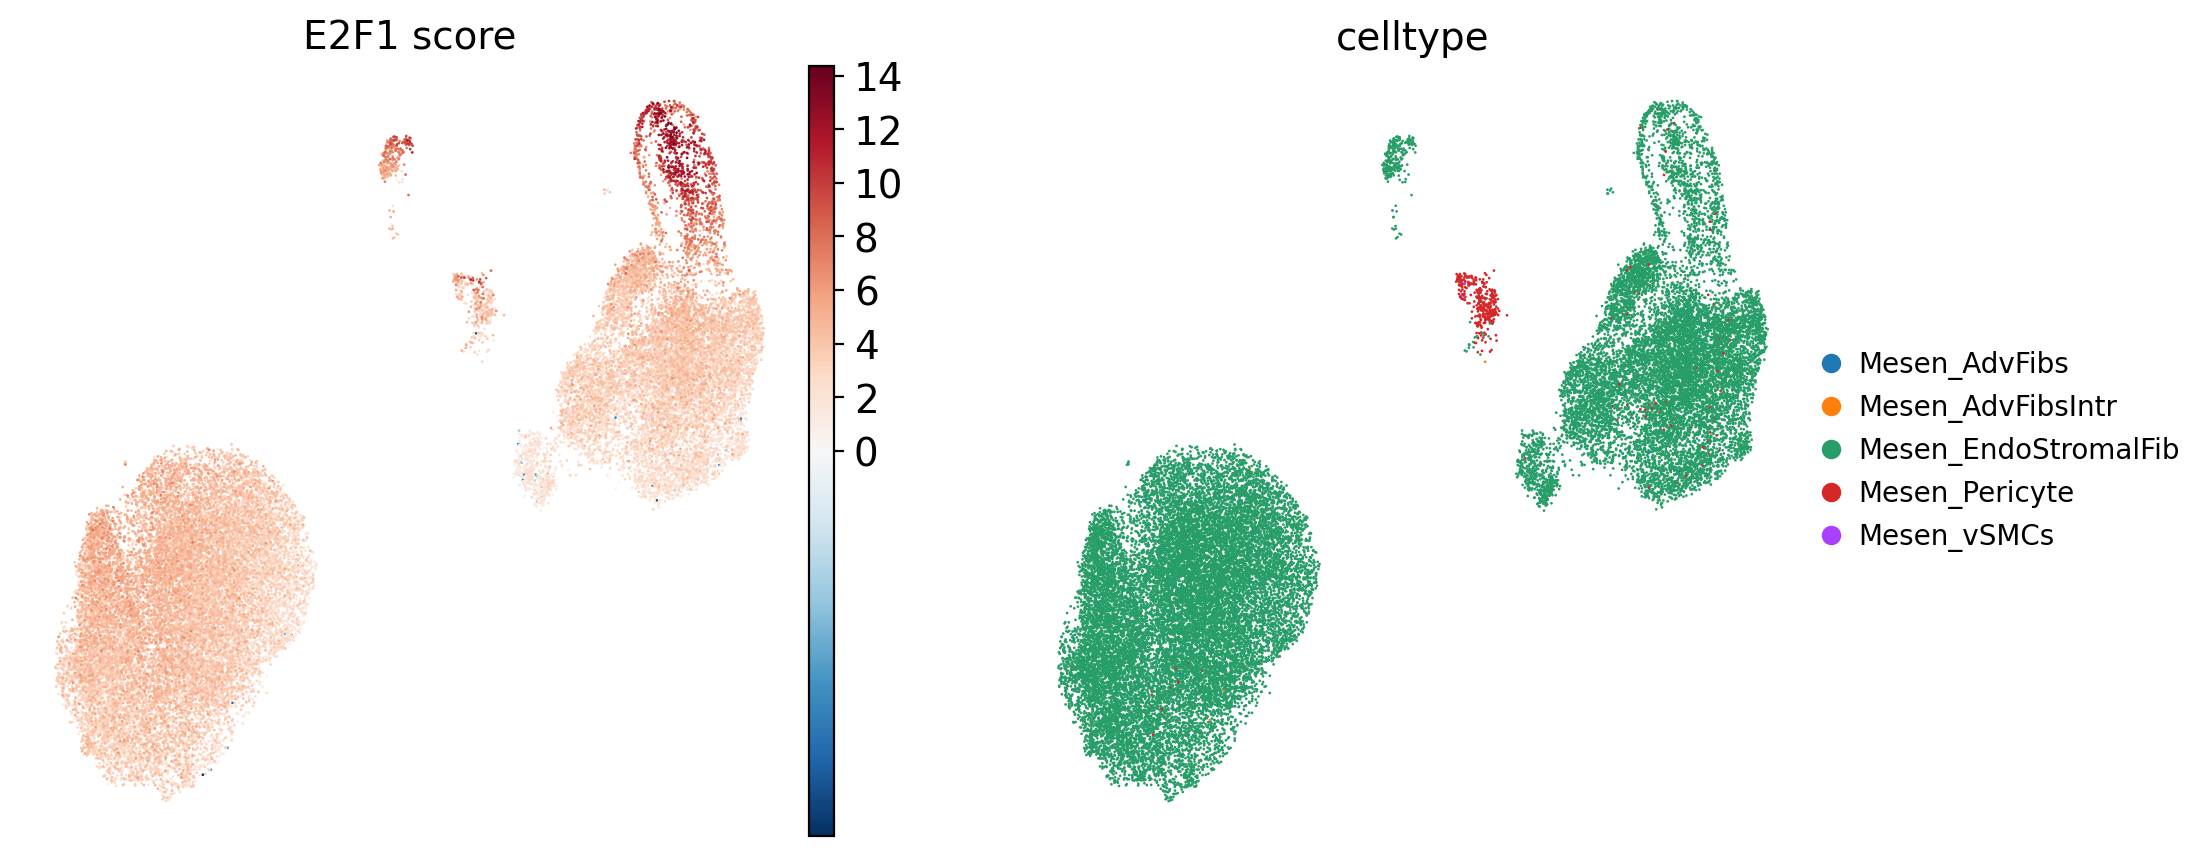

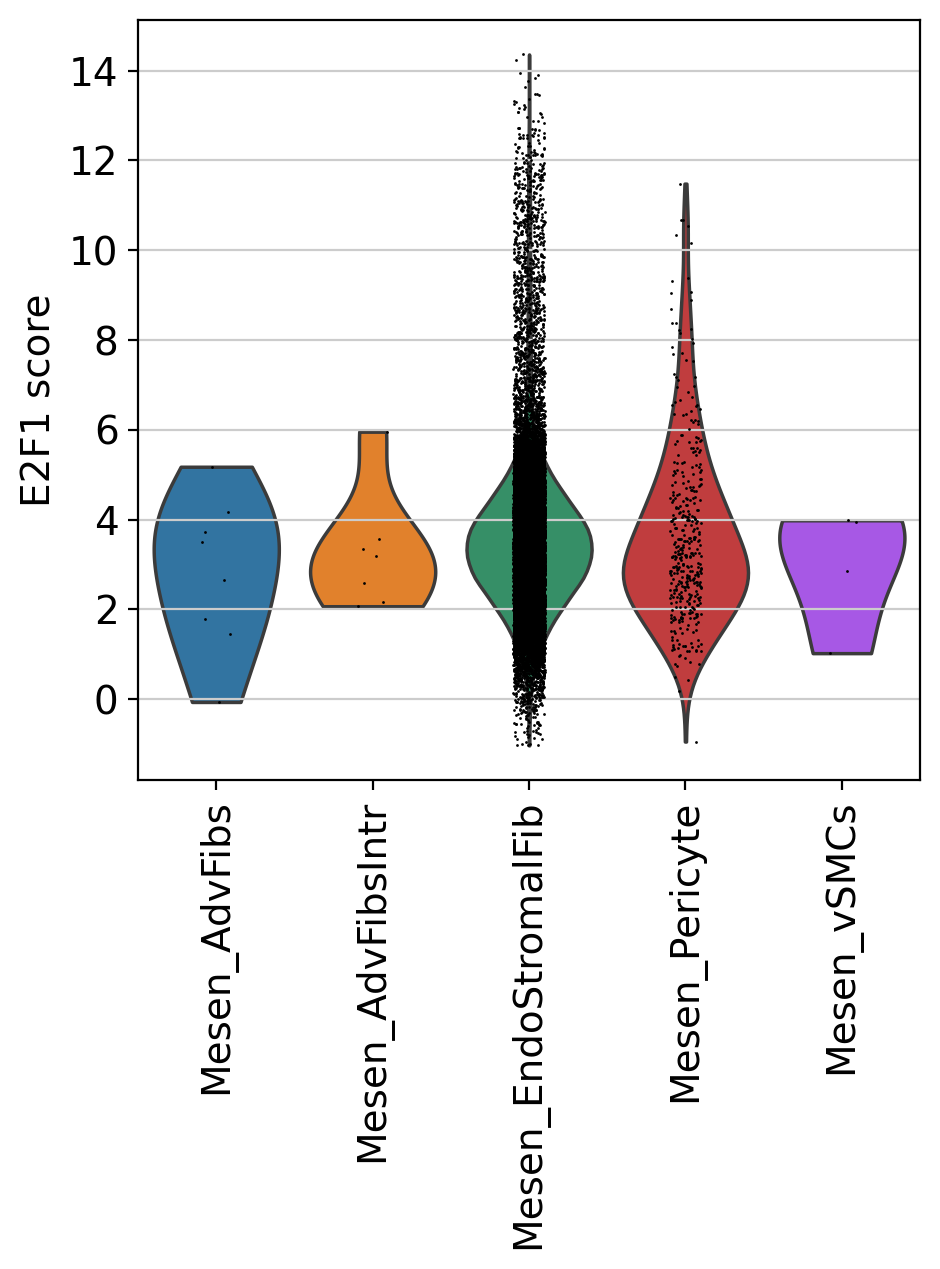

In [ ]:
tf = "E2F1"  # Change to any TF in score.var_names to explore others
sc.pl.umap(score, color=[tf, "celltype"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "celltype"])
sc.pl.violin(score, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} score")

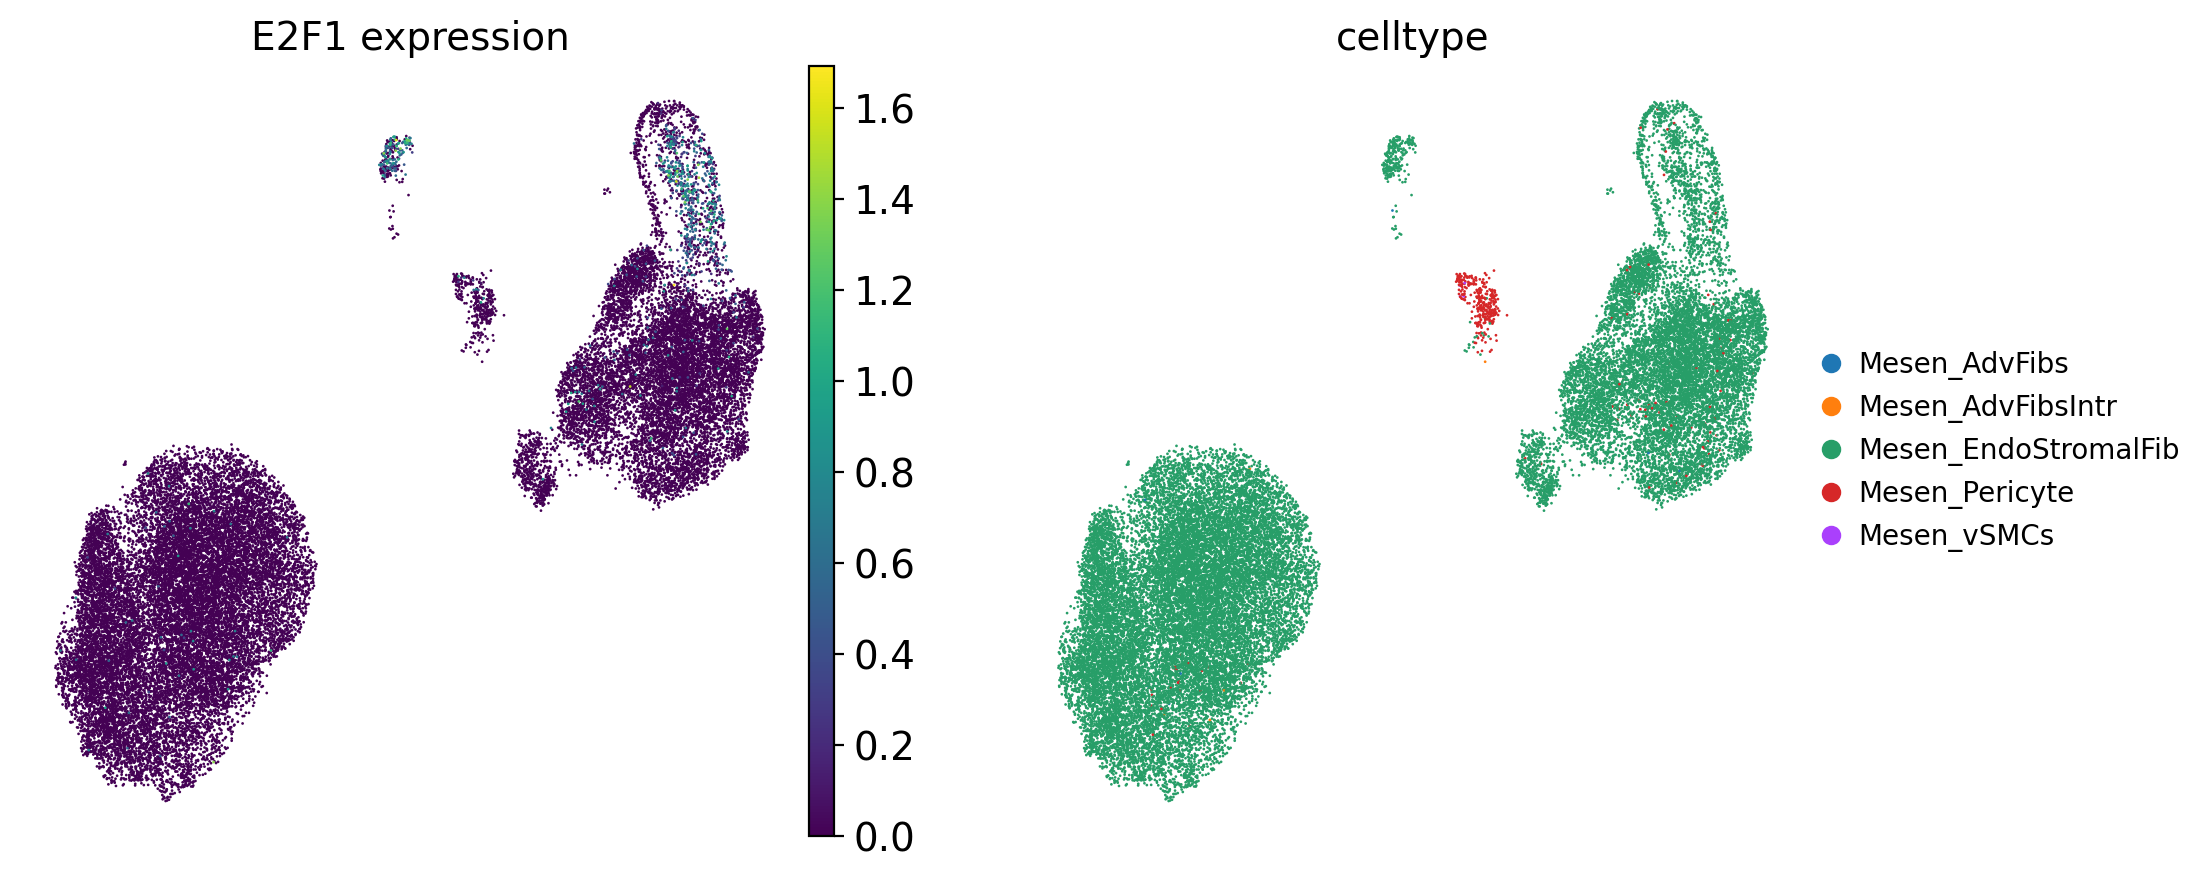

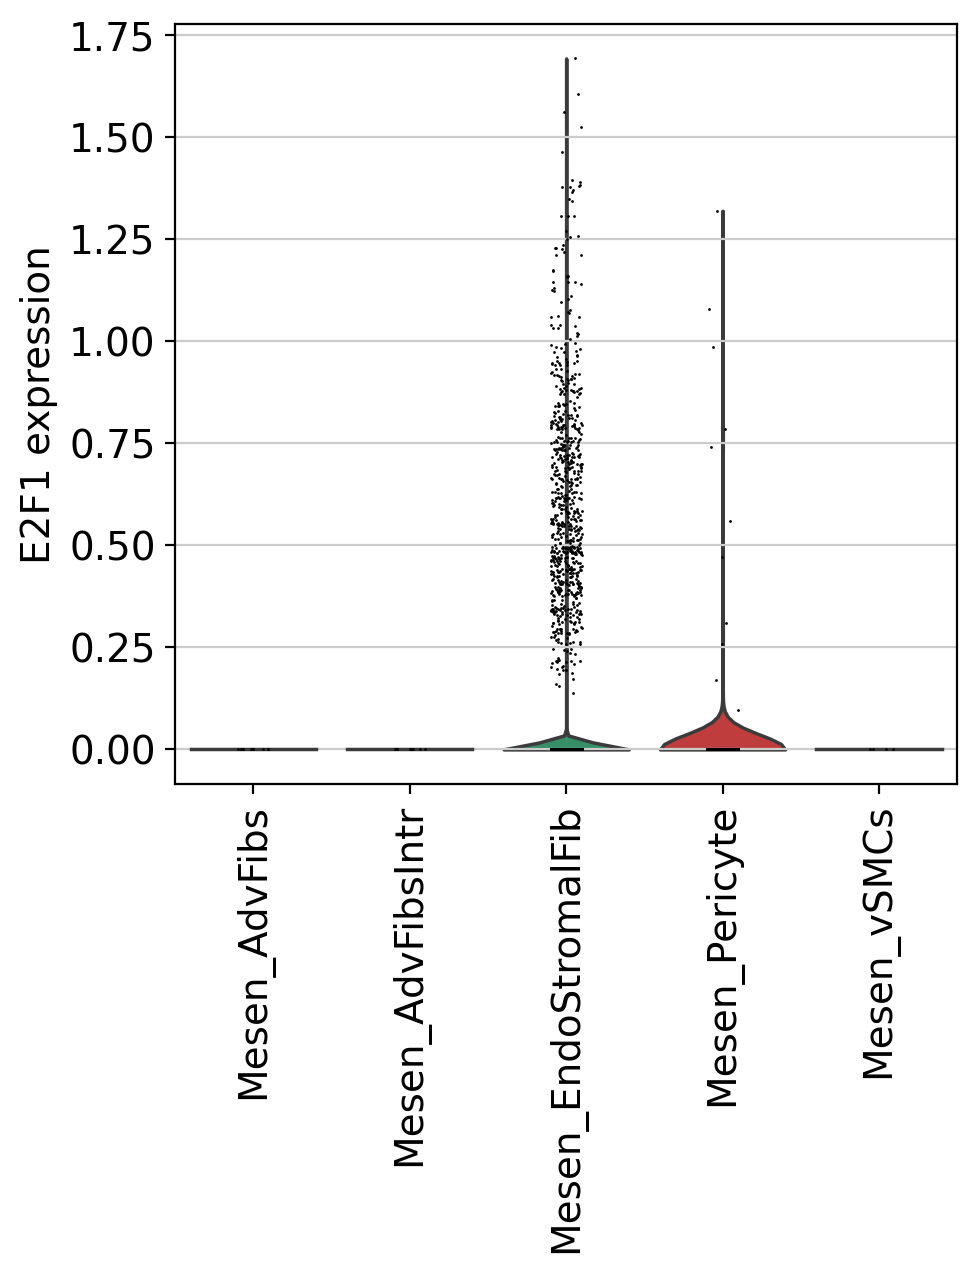

In [ ]:
sc.pl.umap(adata_gsa, color=[tf, "celltype"], title=[f"{tf} expression", "celltype"])
sc.pl.violin(adata_gsa, keys=[tf], groupby="celltype", rotation=90, ylabel=f"{tf} expression")

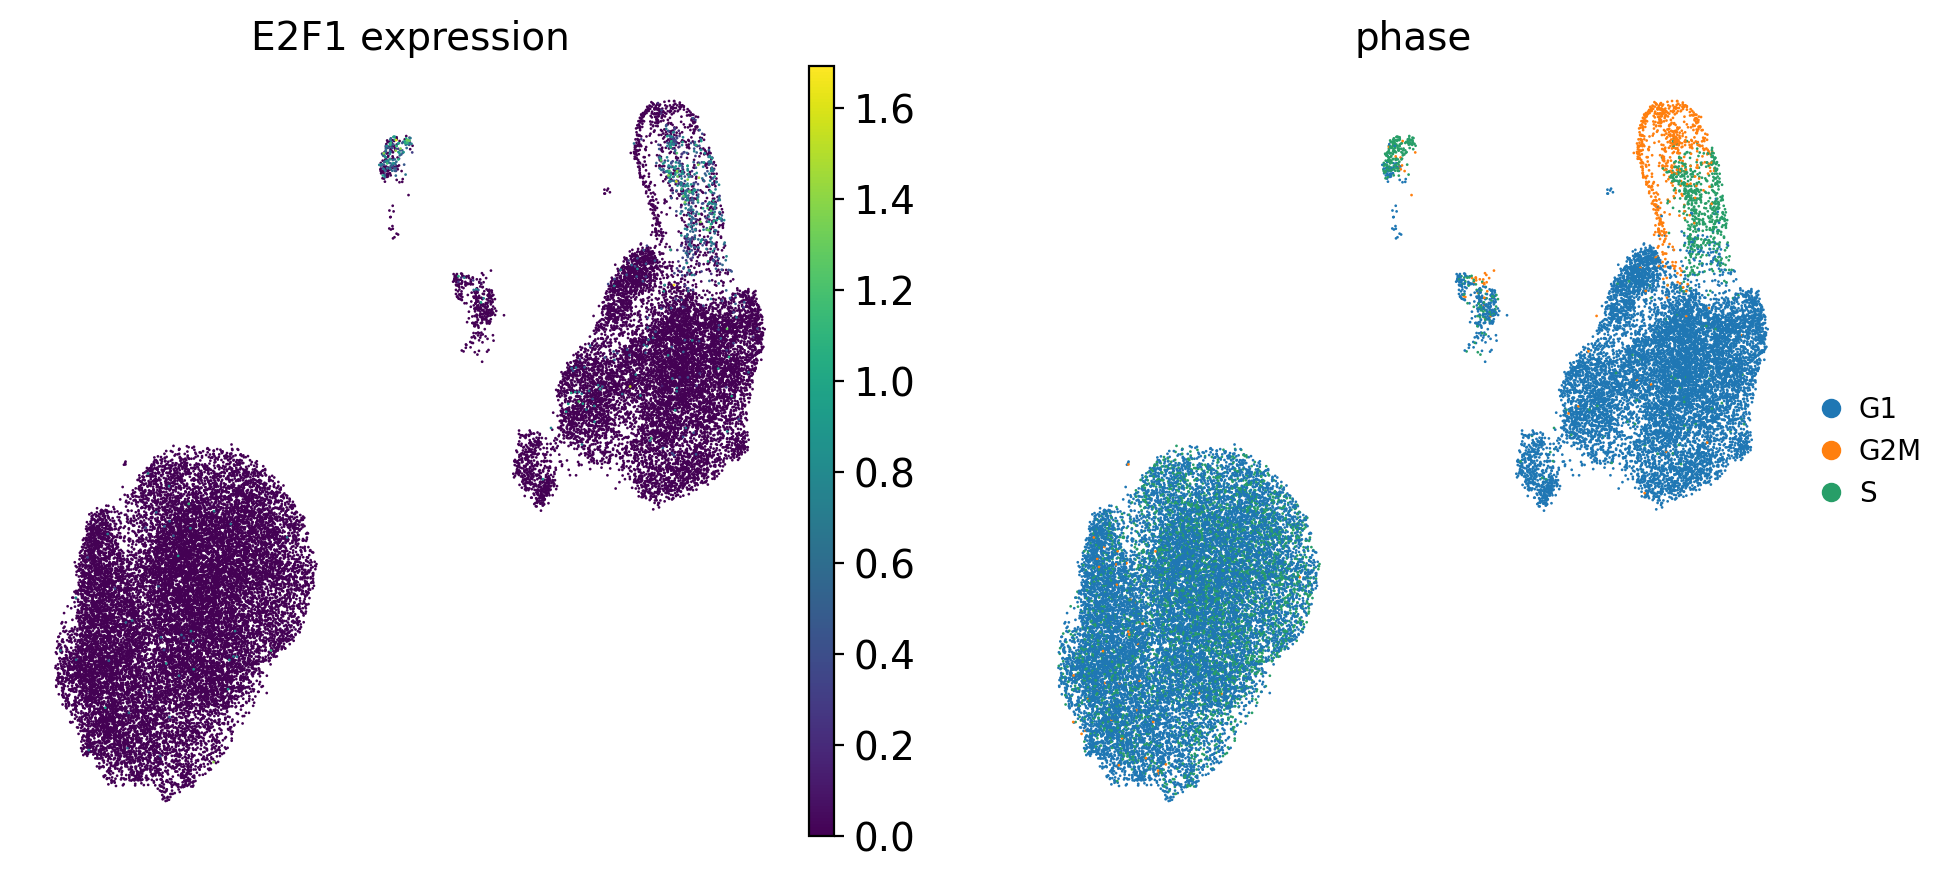

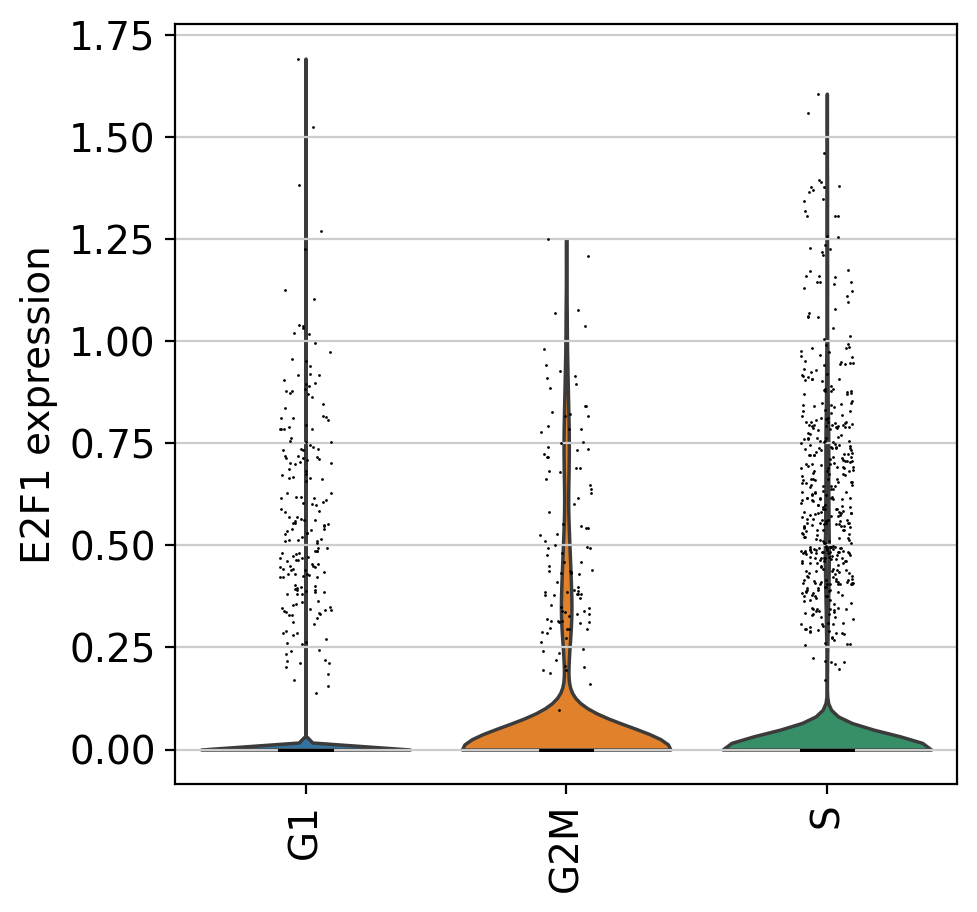

In [ ]:
sc.pl.umap(adata_gsa, color=[tf, "phase"], title=[f"{tf} expression", "phase"])
sc.pl.violin(adata_gsa, keys=[tf], groupby="phase", rotation=90, ylabel=f"{tf} expression")

### Identify cell-type-specific TFs

`dc.tl.rankby_group()` tests each TF against all other cell types pooled (`reference="rest"`) using a t-test. Only TFs with a positive t-statistic are retained, focusing on markers of enrichment rather than depletion.

In [ ]:
df = dc.tl.rankby_group(adata=score, groupby="celltype", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]  # keep only upregulated TFs (positive t-statistic)
df

,group,reference,name,stat,meanchange,pval,padj
0,Mesen_EndoStromalFib,rest,OTX2,214.191952,1.516903,0.000000,0.000000
1,Mesen_EndoStromalFib,rest,MIXL1,192.930407,1.363890,0.000000,0.000000
2,Mesen_EndoStromalFib,rest,ARX,163.174410,1.746047,0.000000,0.000000
3,Mesen_EndoStromalFib,rest,FOXA3,157.298514,1.010428,0.000000,0.000000
4,Mesen_EndoStromalFib,rest,NKX6-2,154.629376,1.526514,0.000000,0.000000
...,...,...,...,...,...,...,...
3737,Mesen_AdvFibsIntr,rest,ATF1,0.005536,0.005993,0.995674,0.998635
3740,Mesen_AdvFibsIntr,rest,SOX4,0.003463,0.002711,0.997295,0.998635
3741,Mesen_AdvFibsIntr,rest,NEUROG3,0.002806,0.001164,0.997807,0.998635
3743,Mesen_AdvFibsIntr,rest,NONO,0.002587,0.001618,0.997983,0.998635


In [ ]:
n_markers = 3

source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

{'Mesen_AdvFibs': ['LMX1A', 'LMO2', 'ATF7'],
 'Mesen_AdvFibsIntr': ['ZNF350', 'FOXC2', 'SOX2'],
 'Mesen_EndoStromalFib': ['OTX2', 'MIXL1', 'ARX'],
 'Mesen_Pericyte': ['LMX1B', 'CEBPZ', 'EBF1'],
 'Mesen_vSMCs': ['FOXH1', 'PRDM2', 'POU4F3']}

### Summarise top TFs per cell type

Collect the top 3 TFs per cell type and display them as a matrixplot. Z-scaling each TF column (`standard_scale="var"`) centres the colour axis so inter-group differences are easy to read; the dendrogram clusters cell types with similar TF activity profiles together.

computing PCA
    with n_comps=50
    finished (0:00:01)
Storing dendrogram info using `.uns['dendrogram_celltype']`


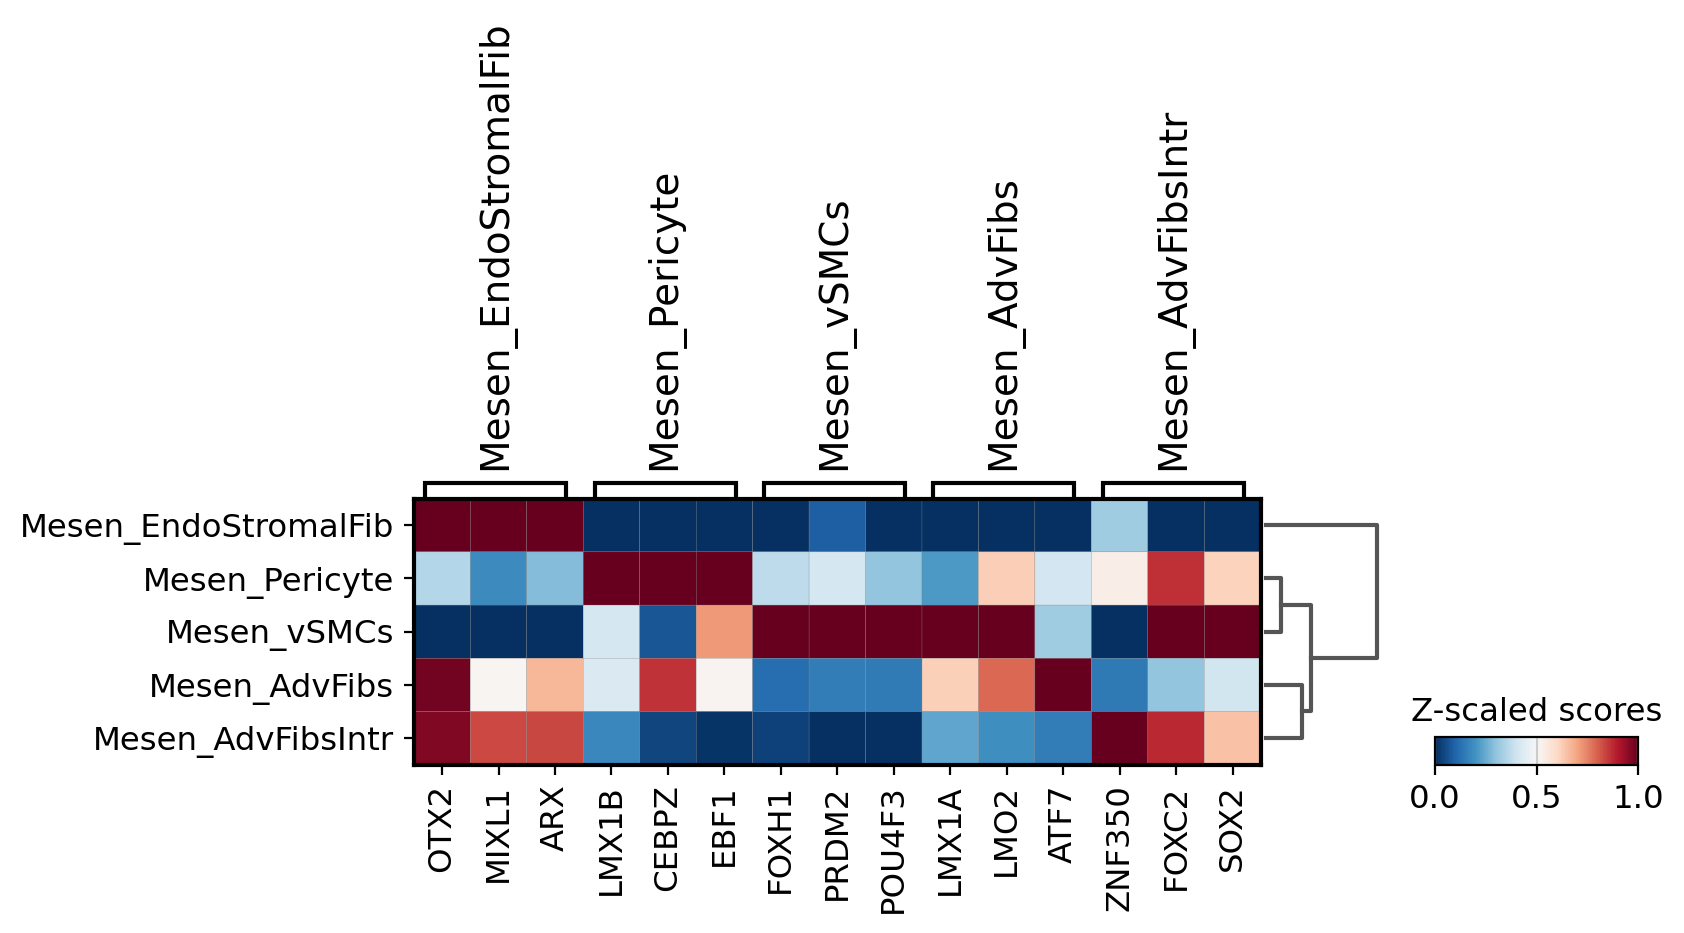

In [ ]:
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="celltype",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

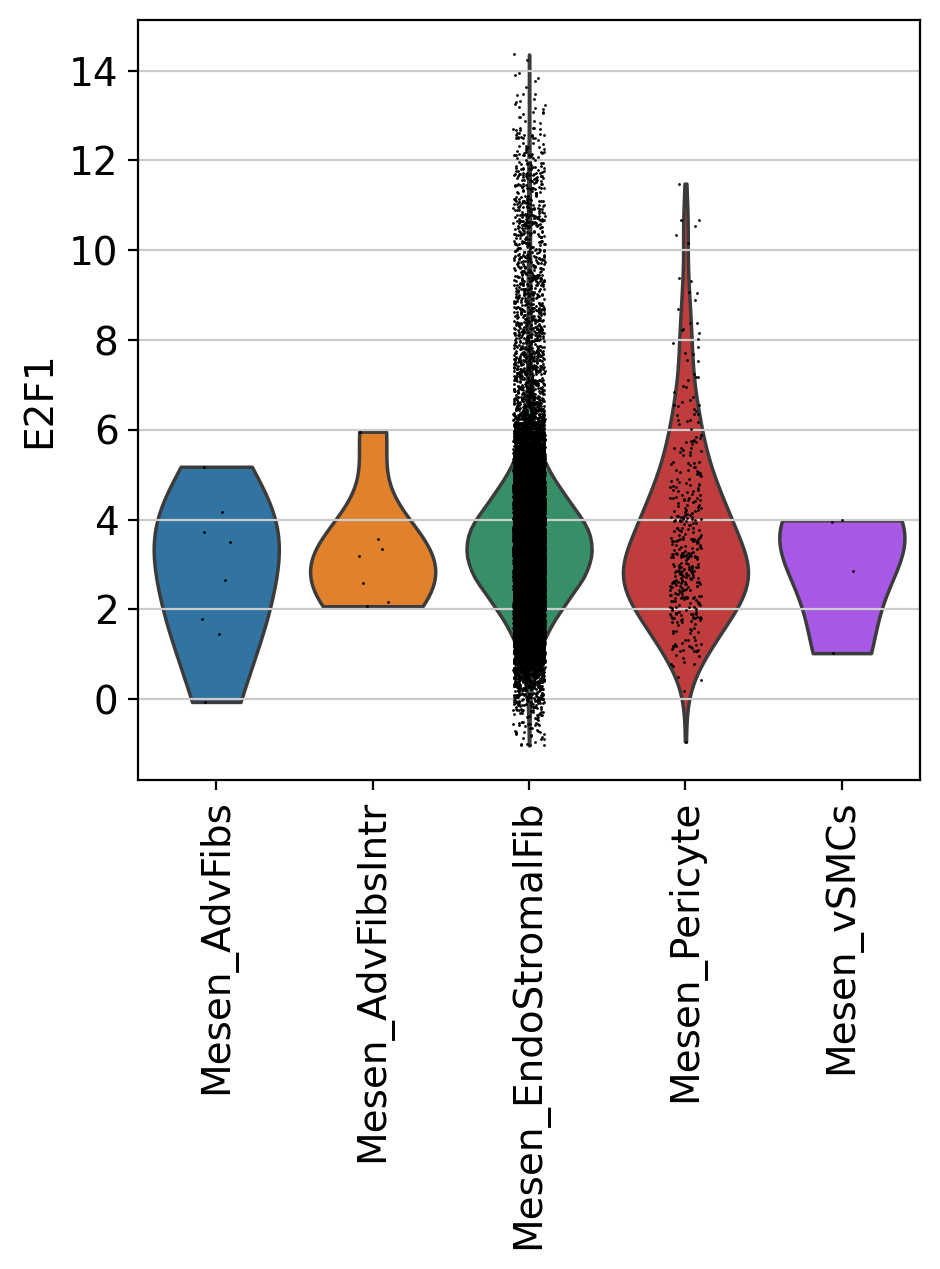

In [ ]:
sc.pl.violin(score, keys=["E2F1"], groupby="celltype", rotation=90)

## 16. Pathway enrichment analysis

Complementary to TF enrichment, **pathway enrichment analysis** infers the activity of known biological signalling pathways and gene programmes from expression data. This answers questions such as: *which signalling cascades are most active in each cell type, and how do they differ across conditions?*

We apply the same ULM-based framework used in section 15, but with two different pathway resources:

- **PROGENy** (`dc.op.progeny()`): a set of 14 curated signalling pathways (e.g. TGFβ, WNT, VEGF, p53, JAK-STAT) derived from large-scale perturbation experiments. Because PROGENy target genes are selected based on *downstream transcriptional response* rather than pathway membership lists, it is more sensitive and interpretable than classic over-representation approaches.
- **Hallmark gene sets** (`dc.op.hallmark()`): 50 well-defined biological states and processes from the MSigDB Hallmark collection. These represent coherent, low-noise signatures (e.g. *Epithelial-Mesenchymal Transition*, *Inflammatory Response*, *G2M Checkpoint*) and are a standard reference for broad programme-level comparisons.

**Pipeline:**
1. Load the **PROGENy** pathway network and score pathway activity per cell with ULM.
2. Extract and visualise PROGENy activity scores (heatmap, UMAP, violin).
3. Load the **MSigDB Hallmark** gene sets and score hallmark activity per cell with ULM.
4. Rank hallmark programmes per cell type using a t-test and extract top discriminating programmes.
5. Summarise top hallmarks per cell type on a dotplot / matrixplot.

### PROGENy — score signalling pathway activity

Load **PROGENy**, a network of 14 curated signalling pathways (Androgen, EGFR, Estrogen, Hypoxia, JAK-STAT, MAPK, NFkB, PI3K, TGFb, TNFa, Trail, VEGF, WNT, p53). Unlike classical gene-set overlap methods, PROGENy weights each target gene by its measured transcriptional response to pathway activation, making activity scores more sensitive to subtle shifts.

In [ ]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


Score pathway activity per cell using ULM — the same approach as TF enrichment in section 15. Results are stored in `adata_gsa.obsm["score_ulm"]`.

In [ ]:
dc.mt.ulm(data=adata_gsa, net=progeny)

Extract PROGENy activity scores as a standalone AnnData. `obs` corresponds to cells and `var` to the 14 PROGENy pathways.

In [ ]:
score = dc.pp.get_obsm(adata=adata_gsa, key="score_ulm")
score

AnnData object with n_obs × n_vars = 31395 × 14
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'Cohen2026_lineage', 'Cohen2026_broad_celltype', 'Cohen2026_fine_celltype', 'celltype', 'leiden_res_0.5', 'leiden_res_1.0',

Inspect which pathways are available in the PROGENy network.

In [ ]:
set(progeny.source)

{'Androgen',
 'EGFR',
 'Estrogen',
 'Hypoxia',
 'JAK-STAT',
 'MAPK',
 'NFkB',
 'PI3K',
 'TGFb',
 'TNFa',
 'Trail',
 'VEGF',
 'WNT',
 'p53'}

### Visualise pathway activity

Explore individual pathway activity on UMAP and violin. Change `"Estrogen"` to any pathway name from `set(progeny.source)` to explore others. `vcenter=0` anchors the diverging colourmap at zero activity.

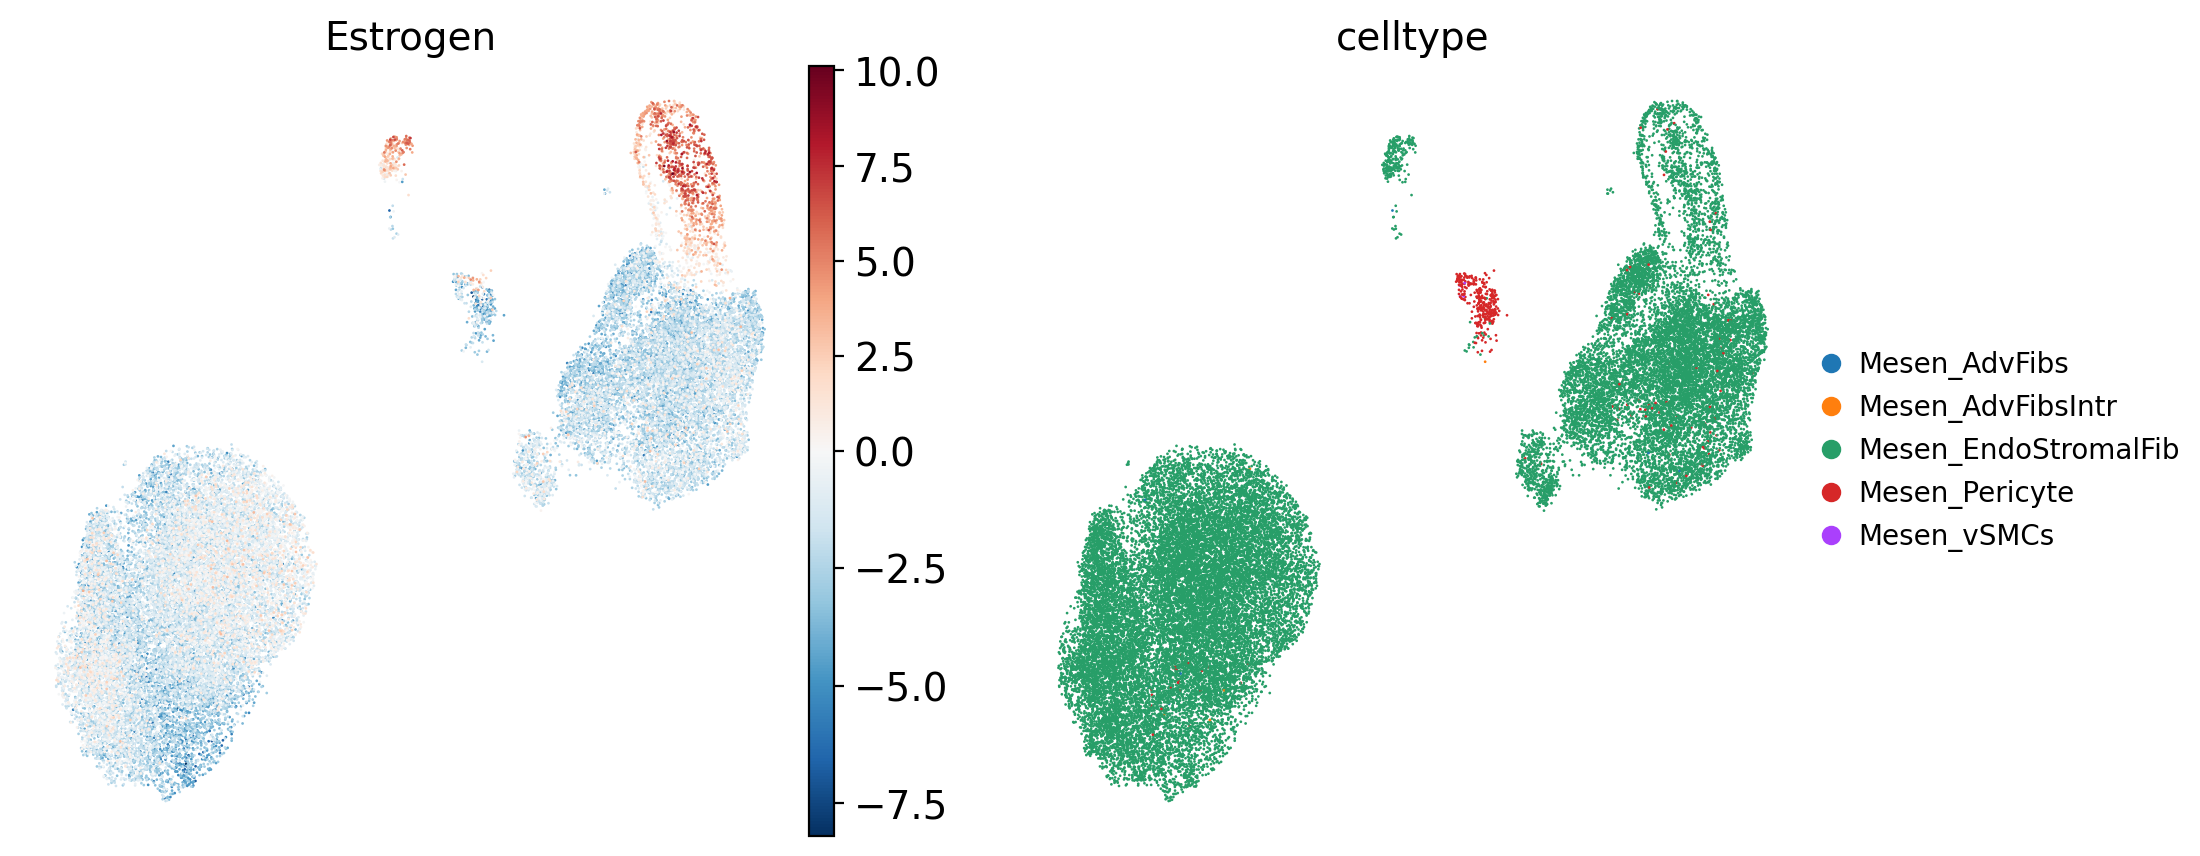

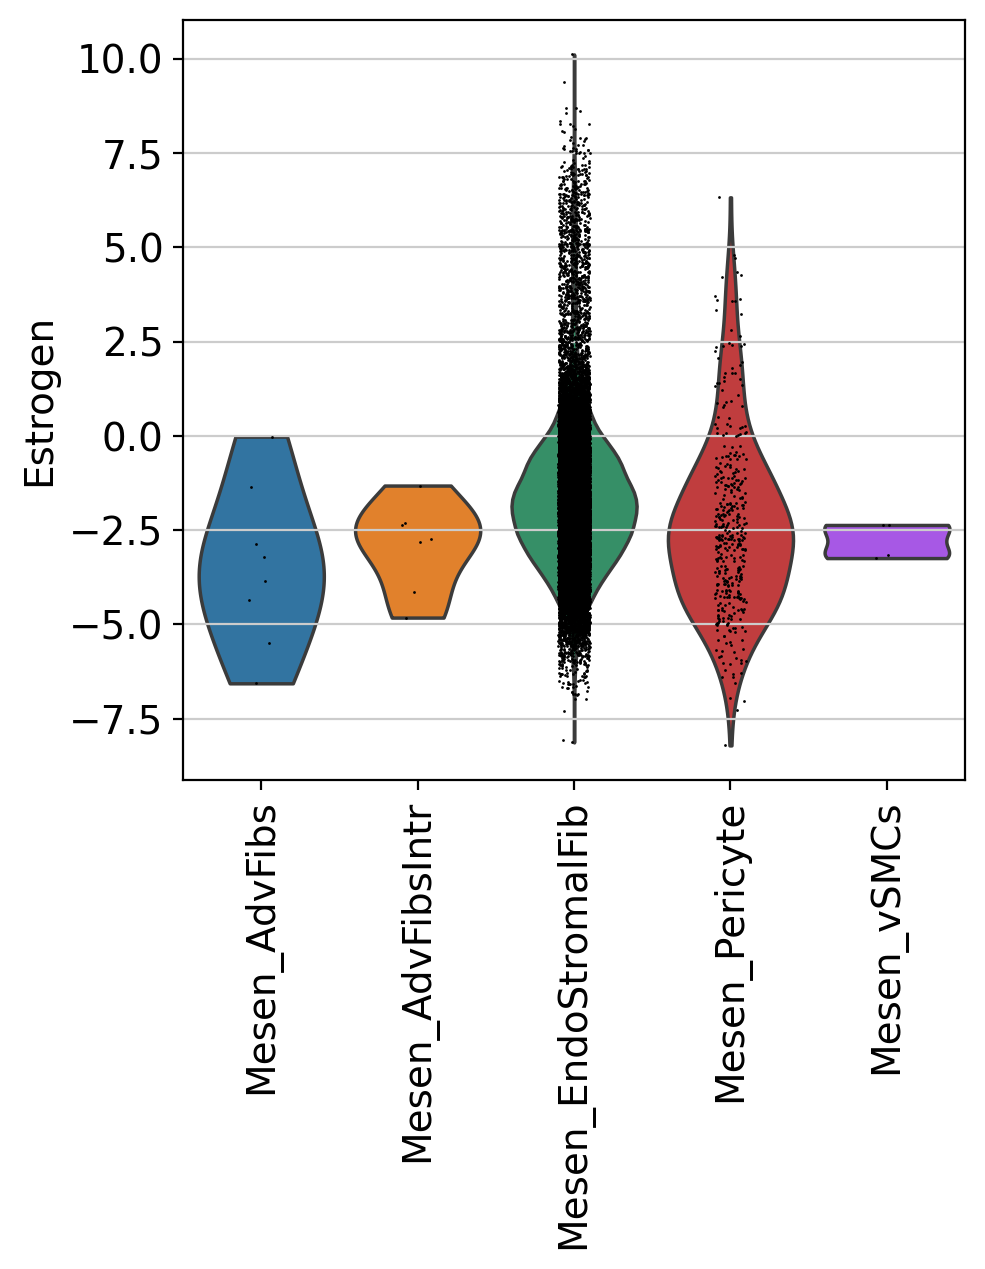

In [ ]:
sc.pl.umap(score, color=["Estrogen", "celltype"], cmap="RdBu_r", vcenter=0)
sc.pl.violin(score, keys=["Estrogen"], groupby="celltype", rotation=90)

With only 14 pathways, all can be displayed at once in a single matrixplot — no marker selection step is needed.

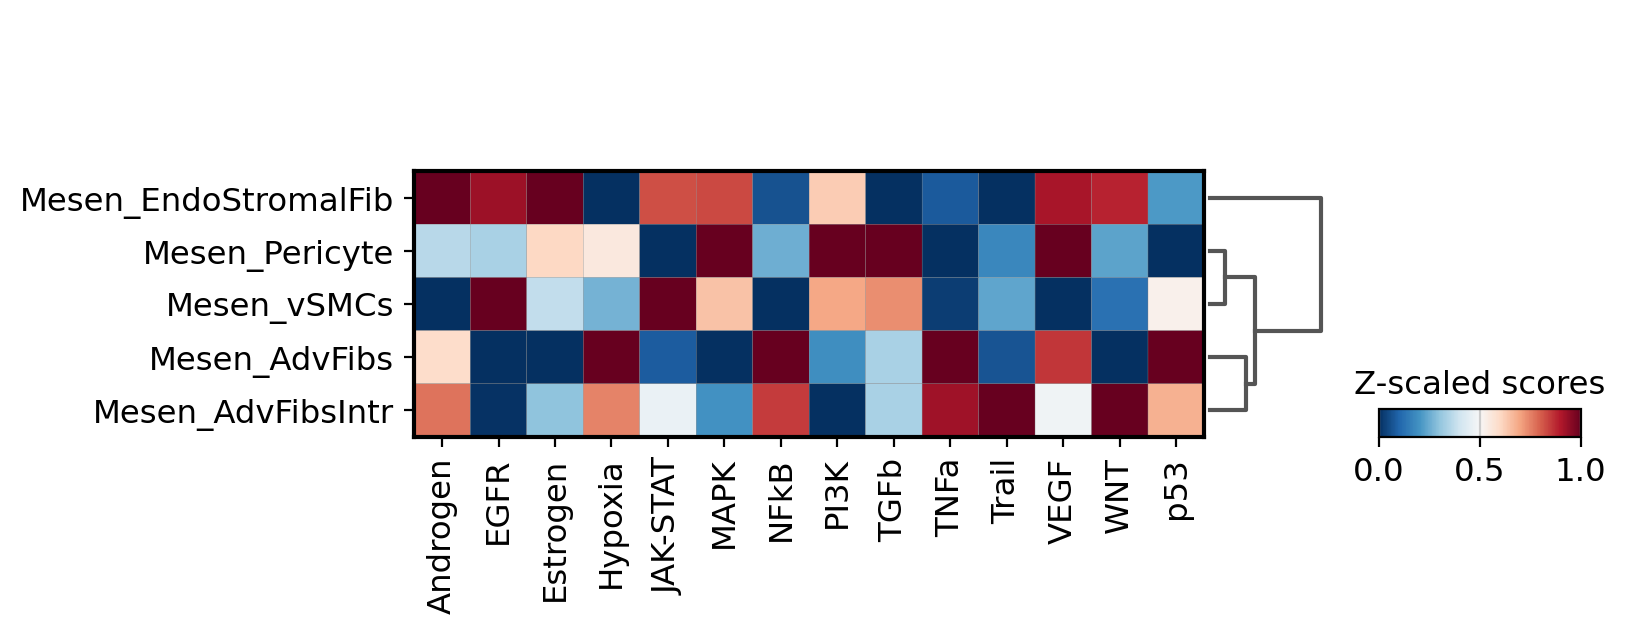

In [ ]:
sc.pl.matrixplot(
    adata=score,
    var_names=score.var_names,
    groupby="celltype",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)

Violin plots allow a side-by-side comparison of activity distributions for two pathways of interest across cell types.

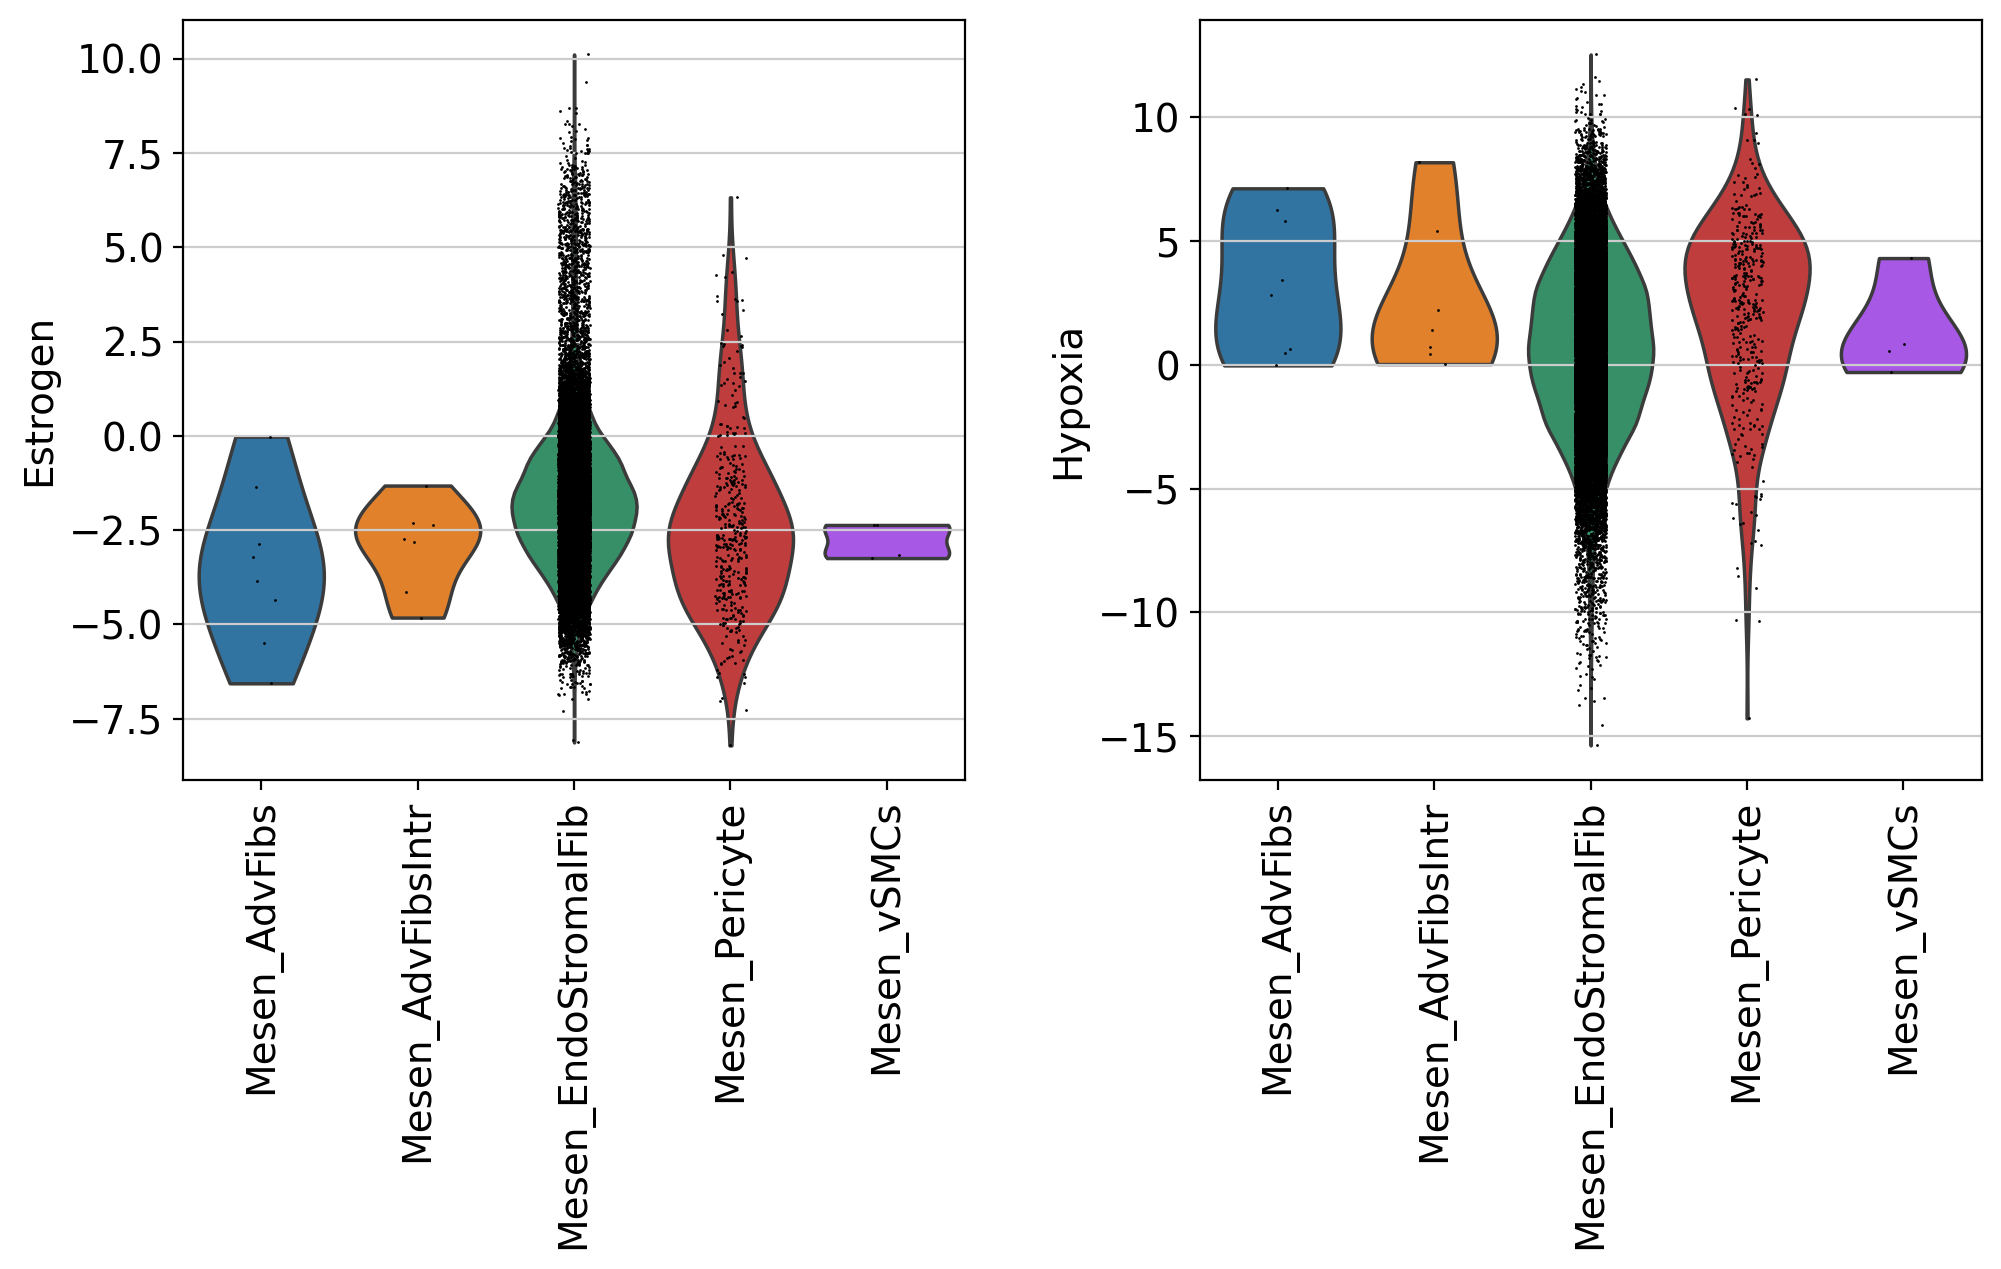

In [ ]:
sc.pl.violin(score, keys=["Estrogen", "Hypoxia"], groupby="celltype", rotation=90)

### MSigDB Hallmark gene sets — score biological programmes

Load the **Hallmark** collection (50 biological programmes from MSigDB), e.g. *Epithelial–Mesenchymal Transition*, *G2M Checkpoint*, *Inflammatory Response*. Hallmark sets are refined to coherent, low-noise signatures representing well-characterised biological states. The same ULM scoring is applied, but the score now represents the activity of a biological programme rather than a signalling cascade.

Note: this call overwrites `adata_gsa.obsm["score_ulm"]` with Hallmark-based scores.

In [ ]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


In [ ]:
dc.mt.ulm(data=adata_gsa, net=hallmark)

In [ ]:
score = dc.pp.get_obsm(adata=adata_gsa, key="score_ulm")
score

AnnData object with n_obs × n_vars = 31395 × 50
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'Cohen2026_lineage', 'Cohen2026_broad_celltype', 'Cohen2026_fine_celltype', 'celltype', 'leiden_res_0.5', 'leiden_res_1.0',

### Identify cell-type-specific Hallmark programmes

With 50 programmes it is more informative to rank them statistically rather than display all at once. The same `rankby_group` approach as in section 15 identifies the programmes that best discriminate each cell type from the rest.

In [ ]:
df = dc.tl.rankby_group(adata=score, groupby="celltype", reference="rest", method="t-test_overestim_var")
df = df[df["stat"] > 0]  # keep only upregulated programmes (positive t-statistic)
df

,group,reference,name,stat,meanchange,pval,padj
0,Mesen_EndoStromalFib,rest,XENOBIOTIC_METABOLISM,149.150060,1.776517,0.000000,0.000000
1,Mesen_EndoStromalFib,rest,ESTROGEN_RESPONSE_LATE,105.553035,1.060998,0.000000,0.000000
2,Mesen_EndoStromalFib,rest,BILE_ACID_METABOLISM,92.690004,0.677357,0.000000,0.000000
3,Mesen_EndoStromalFib,rest,GLYCOLYSIS,91.022891,1.271551,0.000000,0.000000
4,Mesen_EndoStromalFib,rest,PANCREAS_BETA_CELLS,91.017031,0.664263,0.000000,0.000000
...,...,...,...,...,...,...,...
239,Mesen_AdvFibsIntr,rest,KRAS_SIGNALING_DN,0.328210,0.108896,0.748798,0.934426
243,Mesen_AdvFibsIntr,rest,FATTY_ACID_METABOLISM,0.198795,0.183840,0.846011,0.961376
244,Mesen_AdvFibsIntr,rest,ADIPOGENESIS,0.111262,0.126329,0.913441,0.970301
245,Mesen_AdvFibsIntr,rest,UV_RESPONSE_UP,0.087019,0.083775,0.932445,0.970301


In [ ]:
n_markers = 3

source_markers = (
    df.groupby("group")
    .head(n_markers)
    .drop_duplicates("name")
    .groupby("group")["name"]
    .apply(lambda x: list(x))
    .to_dict()
)
source_markers

{'Mesen_AdvFibs': ['EPITHELIAL_MESENCHYMAL_TRANSITION', 'COAGULATION'],
 'Mesen_AdvFibsIntr': [],
 'Mesen_EndoStromalFib': ['XENOBIOTIC_METABOLISM',
  'ESTROGEN_RESPONSE_LATE',
  'BILE_ACID_METABOLISM'],
 'Mesen_Pericyte': ['MYOGENESIS', 'APICAL_JUNCTION', 'NOTCH_SIGNALING'],
 'Mesen_vSMCs': ['KRAS_SIGNALING_DN']}

### Summarise top Hallmark programmes per cell type

Collect the top 3 programmes per cell type and display on a matrixplot, mirroring the TF analysis above.

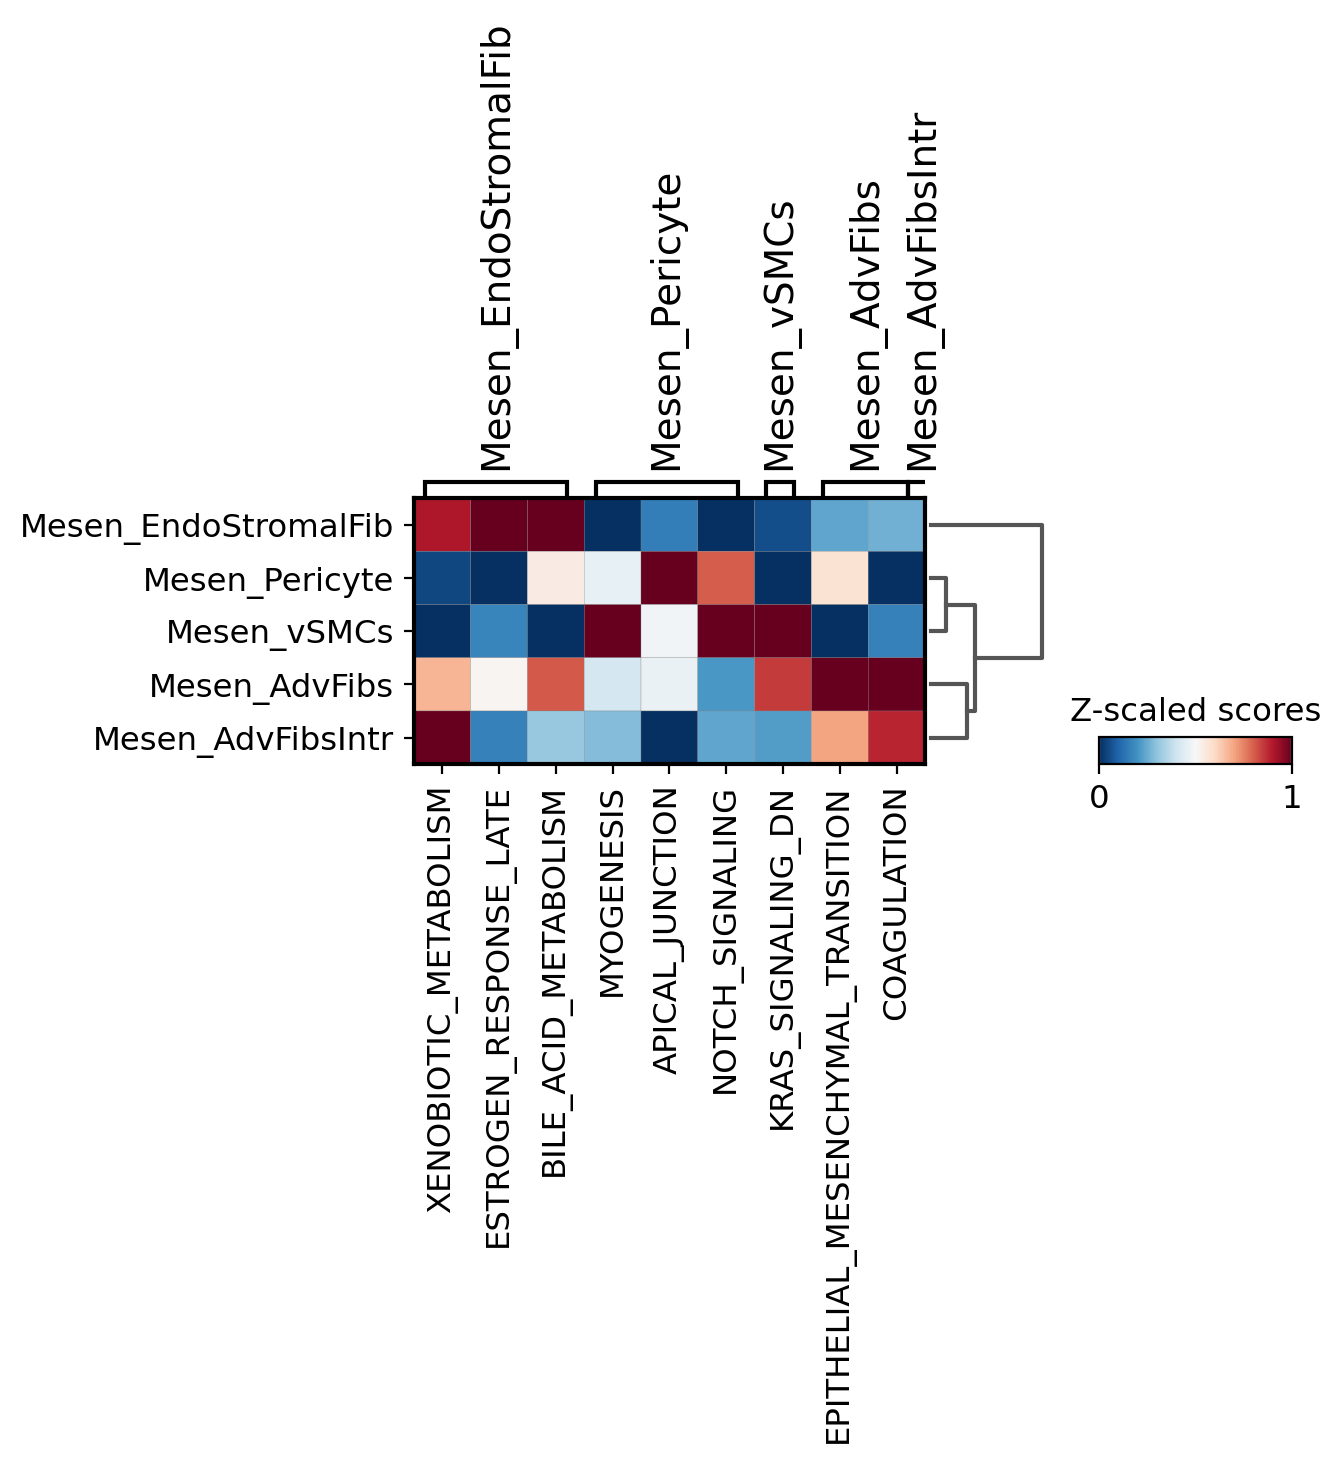

In [ ]:
sc.pl.matrixplot(
    adata=score,
    var_names=source_markers,
    groupby="celltype",
    dendrogram=True,
    standard_scale="var",
    colorbar_title="Z-scaled scores",
    cmap="RdBu_r",
)